# TIME ANALYSIS: Are categories best?

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import warnings
import seaborn as sns
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from scipy import stats
from scipy.spatial.distance import cdist
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks, argrelextrema
from sklearn.mixture import GaussianMixture
import warnings
warnings.filterwarnings('ignore')

In [32]:
df = pd.read_parquet(
    r"C:\Users\lucyq\Dropbox\AMDP\THESIS\013_data_for_clustering.parquet").copy()
print('Number of accidents: ', df.shape[0],
      '\nNumber of variables:', df.shape[1])

Number of accidents:  14849 
Number of variables: 35


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14849 entries, 0 to 14848
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype                      
---  ------                        --------------  -----                      
 0   Protocollo                    14849 non-null  int64                      
 1   total_injury_severity         14849 non-null  int32                      
 2   max_injury_severity           14849 non-null  int32                      
 3   num_pedestrians_hit           14849 non-null  int64                      
 4   num_male                      14849 non-null  int32                      
 5   num_female                    14849 non-null  int32                      
 6   num_unknown_gender            14849 non-null  int32                      
 7   multiple_pedestrians          14849 non-null  int32                      
 8   severity_winsorized           14849 non-null  int32                      
 9   DataOraIncidente 

In [34]:
df.isnull().sum().sum()

0

In [35]:
# How is TIME currently encoded?
print("\nTIME columns: time_sin and time_cos, dtype:", df['time_sin'].dtype)


TIME columns: time_sin and time_cos, dtype: float64


In [36]:
# Configure fonts and styling
plt.rcParams.update({
    "font.size": 10,
    "figure.dpi": 180,
    "savefig.dpi": 300,
})

sns.set_theme(style="whitegrid", rc={"figure.figsize": (10, 6)})

In [37]:
# ============================================================================
# PART 1: DATA PREPARATION AND BASIC EXPLORATION
# ============================================================================

def sin_cos_to_hour(time_sin, time_cos):
    """Convert sin/cos back to hour (0-24)"""
    angle = np.arctan2(time_sin, time_cos)
    angle = np.where(angle < 0, angle + 2*np.pi, angle)
    return (angle / (2*np.pi)) * 24


# Add hour column for easier interpretation
df['hour'] = sin_cos_to_hour(df['time_sin'], df['time_cos'])

print("="*80)
print("TEMPORAL CLUSTERING ANALYSIS - ROME PEDESTRIAN ACCIDENTS")
print("="*80)
print(f"\nDataset shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}" if isinstance(
    df.index, pd.DatetimeIndex) else "")
print(f"Day distribution:\n{df['DAY_BINARY'].value_counts().sort_index()}")
print(
    f"\nSeverity distribution:\n{df['severity_winsorized'].value_counts().sort_index()}")

# Basic temporal statistics
print("\n" + "="*80)
print("BASIC TEMPORAL STATISTICS")
print("="*80)
print(f"\nMean hour: {df['hour'].mean():.2f}")
print(f"Median hour: {df['hour'].median():.2f}")
print(f"Hour std dev: {df['hour'].std():.2f}")

# Circular statistics (proper for circular data)
mean_angle = np.arctan2(df['time_sin'].mean(), df['time_cos'].mean())
mean_hour_circular = (mean_angle / (2*np.pi) * 24) % 24
r = np.sqrt(df['time_sin'].mean()**2 + df['time_cos'].mean()**2)
print(f"\nCircular mean hour: {mean_hour_circular:.2f}")
print(f"Circular concentration (r): {r:.3f} (0=uniform, 1=concentrated)")

TEMPORAL CLUSTERING ANALYSIS - ROME PEDESTRIAN ACCIDENTS

Dataset shape: (14849, 36)

Day distribution:
DAY_BINARY
Weekday    12268
Weekend     2581
Name: count, dtype: int64

Severity distribution:
severity_winsorized
0     1902
1    11487
2     1074
3      198
4      188
Name: count, dtype: int64

BASIC TEMPORAL STATISTICS

Mean hour: 14.35
Median hour: 14.50
Hour std dev: 4.81

Circular mean hour: 14.80
Circular concentration (r): 0.418 (0=uniform, 1=concentrated)


The issue with using a 'time of day' is that within clusters, we will tend to get the mean time of day (somewhere around 14:35-14:50) with little variation. Evening and morning accidents will balance each other out, making 14:40 seem the peak time for accidents (very dangerous) when actually it isn't. Bins allow us to better identify which sections of the day (morning rush hour, lunchtime, late night, etc) are more dangerous in line with greater flow of vehicle and pedestrian traffic at the beginning and end of the working day. 

Bins lose information; the start of the bin might be several hours from its end, yet accidents at the beginning and end of the time frame are treated the same. However, with gamma greater than 1, including both binned categories and time_sin/time_cos allows the algorithm to cluster according to the bin frames then the time_sin/cos essentially refines the shape inside the bins and help indicate where the peak lies within the bin. This can help reduce the noise of times spread throughout the day.

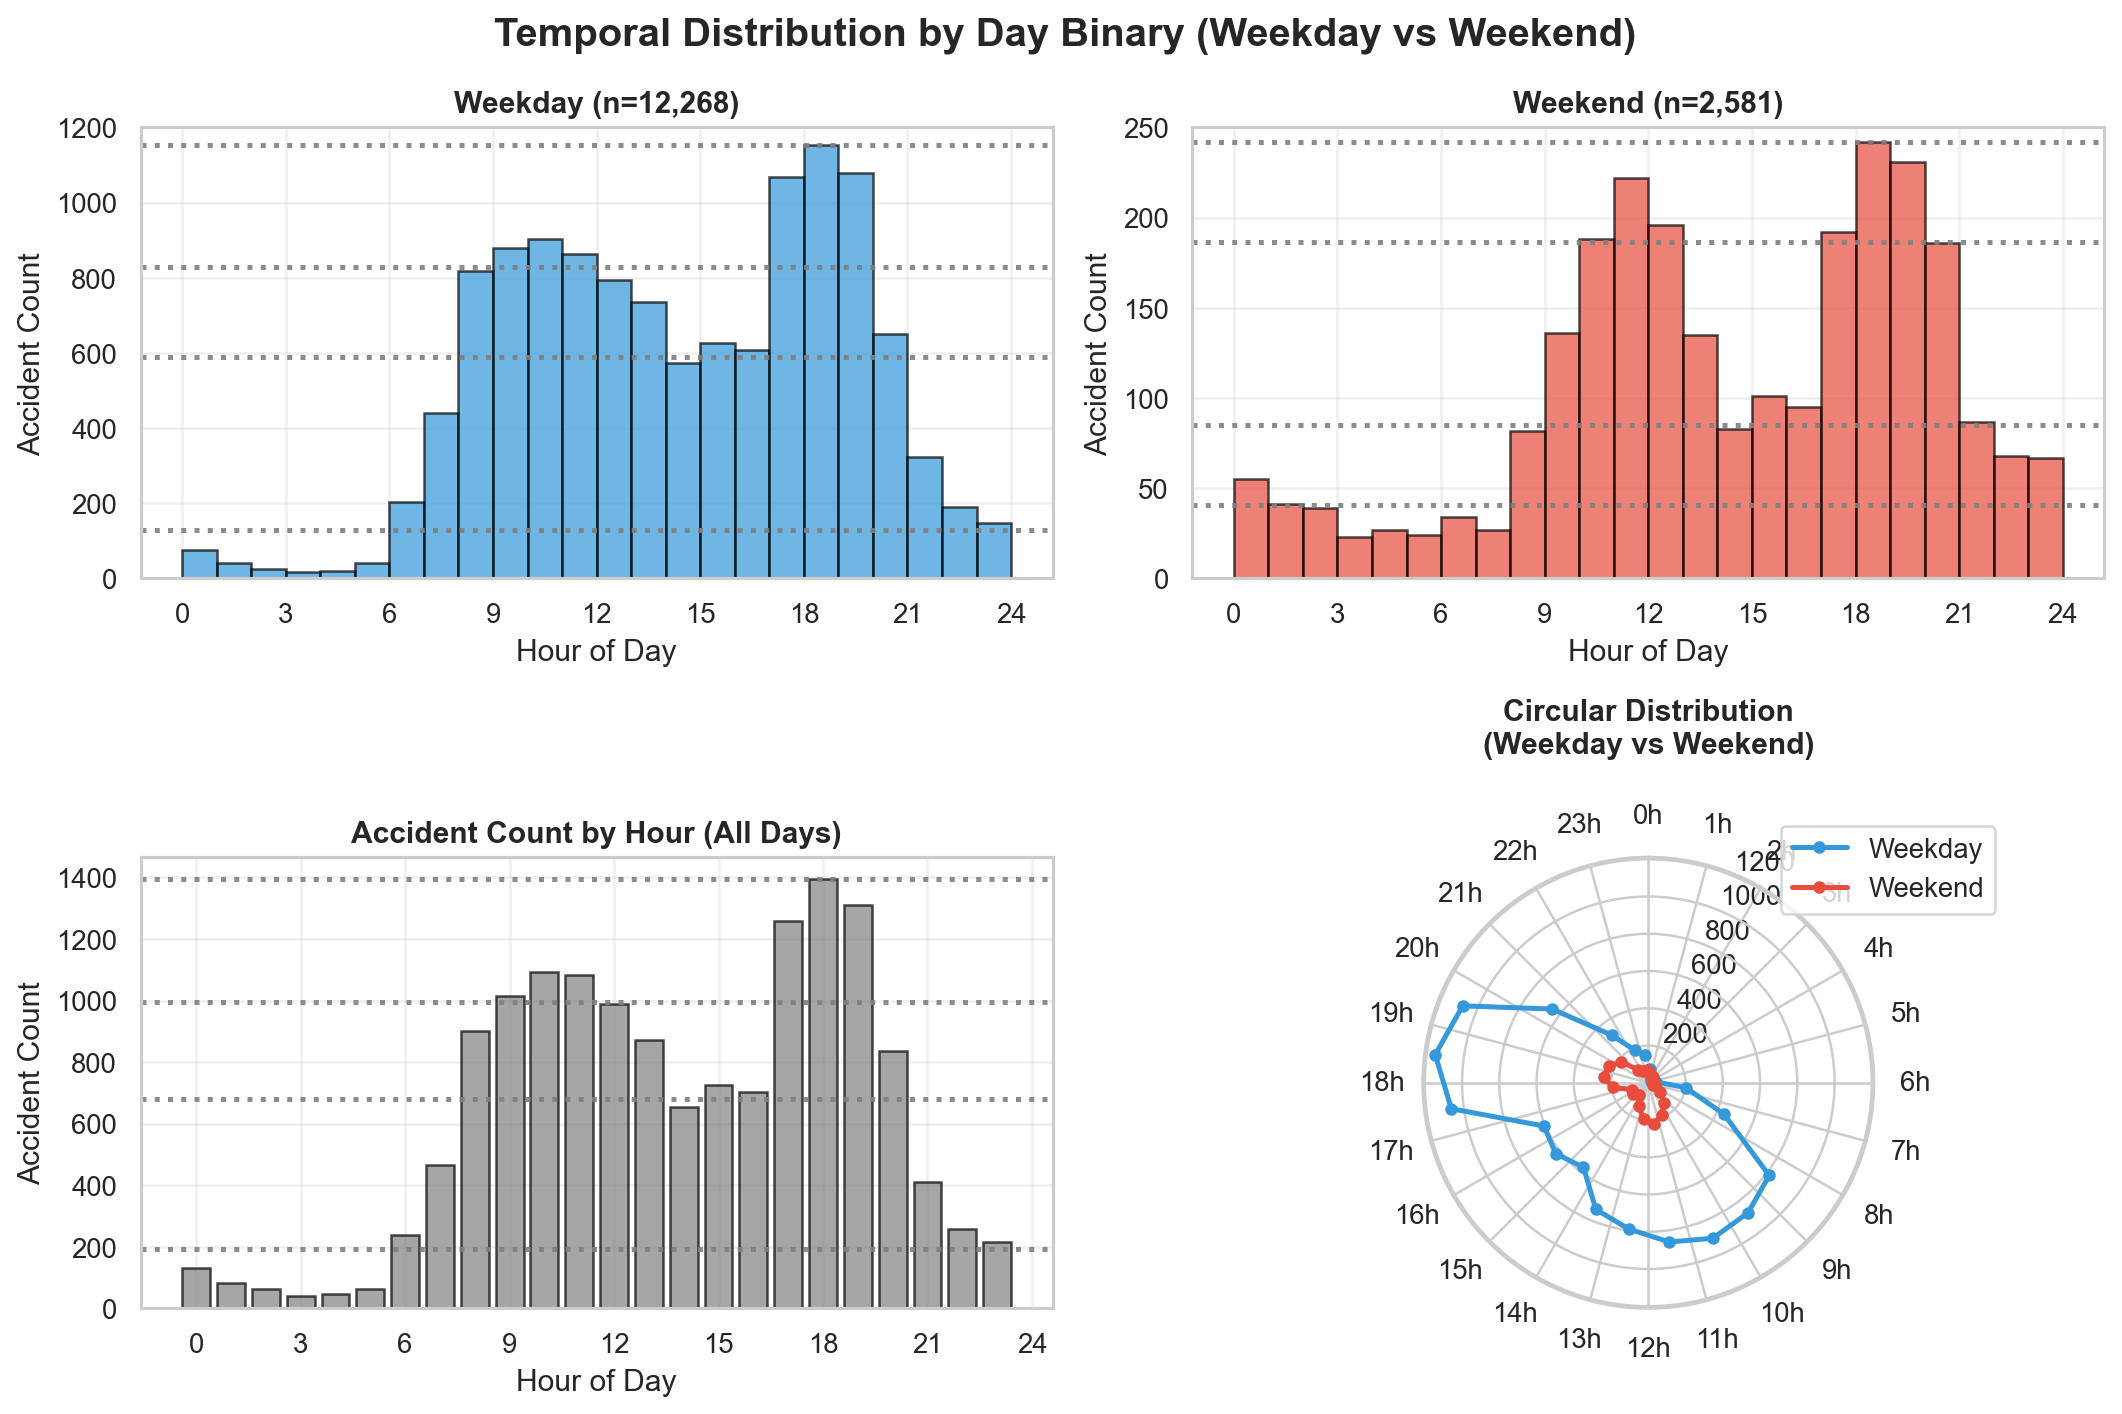

In [38]:
# ============================================================================
# PART 2: VISUALIZE TEMPORAL PATTERNS BY DAY_BINARY
# ============================================================================

# --- figure & layout ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Temporal Distribution by Day Binary (Weekday vs Weekend)',
             fontsize=16, fontweight='semibold')

# Where each day category should go
slot = {
    'Weekday': (0, 0),
    'Weekend': (0, 1)
}
day_categories = ['Weekday', 'Weekend']
colors_day = {
    'Weekday': '#3498db',  # Blue
    'Weekend': '#e74c3c'   # Red/Orange
}

# --- histograms (top row: Weekday and Weekend) ---
for dc in day_categories:
    r, c = slot[dc]
    ax = axes[r, c]
    data_subset = df[df['DAY_BINARY'] == dc]
    hours = data_subset['hour'].to_numpy()

    n, bins, _ = ax.hist(hours, bins=24, range=(0, 24),
                         color=colors_day[dc], alpha=0.7, edgecolor='black')

    # Set y-limits: Weekend gets 250, Weekday gets dynamic
    if dc == 'Weekend':
        ax.set_ylim(0, 250)
        ax.set_yticks([0, 50, 100, 150, 200, 250])
    else:
        max_count = n.max()
        # Round up to nearest 100
        y_limit = int(np.ceil(max_count / 100) * 100)
        ax.set_ylim(0, y_limit)

    ax.set_title(f'{dc} (n={len(data_subset):,})', fontweight='semibold')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Accident Count')
    ax.set_xticks([0, 3, 6, 9, 12, 15, 18, 21, 24])
    ax.grid(True, alpha=0.3)

    # Quartile lines of the per-hour counts
    q_lines = np.quantile(n, [0.25, 0.50, 0.75, 1.00])
    for qy in q_lines:
        ax.axhline(qy, linestyle=':', linewidth=2, color='gray', alpha=0.9)

# --- All-days accident count (bottom-left) ---
ax_all = axes[1, 0]

# Count accidents per hour across ALL days
hourly_counts = df.groupby(df['hour'].astype(int), dropna=True).size()

ax_all.bar(hourly_counts.index, hourly_counts.values,
           color='gray', alpha=0.7, edgecolor='black')

ax_all.set_title('Accident Count by Hour (All Days)', fontweight='semibold')
ax_all.set_xlabel('Hour of Day')
ax_all.set_ylabel('Accident Count')
ax_all.set_xticks([0, 3, 6, 9, 12, 15, 18, 21, 24])
ax_all.grid(True, alpha=0.3)

# Quartile lines of the hourly accident counts
q_lines = np.quantile(hourly_counts.values, [0.25, 0.50, 0.75, 1.00])
for qy in q_lines:
    ax_all.axhline(qy, linestyle=':', linewidth=2, color='gray', alpha=0.9)

# --- Polar plot (bottom-right) ---
# Replace the cartesian axes with a polar one
gs = axes[1, 1].get_gridspec()
axes[1, 1].remove()
ax_polar = fig.add_subplot(gs[1, 1], projection='polar')

for dc in day_categories:
    data_subset = df[df['DAY_BINARY'] == dc]
    angles = (data_subset['hour'] / 24.0) * 2 * np.pi
    bins = np.linspace(0, 2*np.pi, 25)
    counts, _ = np.histogram(angles, bins=bins)
    theta = bins[:-1] + (bins[1]-bins[0])/2
    ax_polar.plot(theta, counts, 'o-', label=dc,
                  color=colors_day[dc], linewidth=2, markersize=4)

ax_polar.set_theta_zero_location('N')
ax_polar.set_theta_direction(-1)
ax_polar.set_title('Circular Distribution\n(Weekday vs Weekend)',
                   fontweight='semibold', pad=20)
ax_polar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax_polar.set_xticks(np.linspace(0, 2*np.pi, 24, endpoint=False))
ax_polar.set_xticklabels([f'{i}h' for i in range(24)])

plt.tight_layout()
plt.savefig('01_temporal_patterns_by_day_binary.png',
            dpi=300, bbox_inches='tight')
plt.show()

**OBSERVATIONS**

1. Volume Difference

Weekdays dominate: 12,268 accidents vs 2,581 on weekends (~4.75x more)
This massive volume difference explains why the "All Days" chart essentially mirrors the weekday pattern

2. Weekday Pattern: Classic Commute Signature
Bimodal rush-hour peaks:

Morning rush (~7-9am): ~850-900 accidents
Evening rush (~5-7pm): Peak at 1,100-1,200 accidents (highest risk period)
Midday lull (~1-3pm): Drops to ~600 accidents
Overnight desert (midnight-6am): Minimal activity (<200)

This screams: Commuter traffic = accident risk
3. Weekend Pattern: Late-Night Leisure
Much flatter, with distinct characteristics:

Late evening peak (~6-8pm): ~240-250 accidents (social/dining hours)
Midday elevation (~10am-2pm): ~190-220 accidents (errands, leisure)
Sustained late-night activity (midnight-3am): ~40-60 accidents (nightlife)
No morning rush: Gradual build from 6am onwards

This suggests: Recreational travel, social activities, potentially impaired driving at night
4. The Polar Plot Tells the Story

Weekday (blue): Pronounced "lobes" at 8am and 6pm = directional risk (commuting)
Weekend (red): Nearly circular = diffuse risk throughout waking hours
Weekend's slight bulge at 7-8pm aligns with evening social activity

5. Risk Profile Differences
Metric                  Weekday         Weekend
Highest risk hour       6pm (~1,200)    7pm (~245)
Safest period           2-5am           3-6am
Pattern shape           Sharp peaks     Gentle waves
Late-night risk         Very low        Moderate

💡 Business Implications
This validates your binary clustering because:

✅ Fundamentally different behaviors: Commuting vs leisure/social
✅ Different intervention strategies needed:

Weekday: Target rush-hour congestion, work-related travel
Weekend: Focus on late-night/impaired driving, recreational hotspots


✅ Clear temporal signatures that would blur if you tried to split weekdays further (Mon vs Fri wouldn't show this stark difference)

The data is screaming: "Weekday = work commute risk, Weekend = leisure/nightlife risk" 🎯

AIM:  Find natural valleys in the time distribution using KDE (best places to cut)  

METHOD: 
- Use Jenks breaks for optimal data-driven clustering
- Apply Gaussian Mixture Models to find statistically optimal groupings

EVALUATION: 
- Evaluate bin balance to avoid categories with low counts


ANALYZING WEEKDAY TEMPORAL PATTERNS

Total accidents in Weekday: 12,268

=== NATURAL PEAKS (High Accident Times) ===
Peak 1: 10.14h (10:08)
Peak 2: 18.45h (18:27)

=== NATURAL VALLEYS (Low Accident Times - Optimal Cut Points) ===
Valley 1: 3.77h (3:46)
Valley 2: 14.70h (14:42)


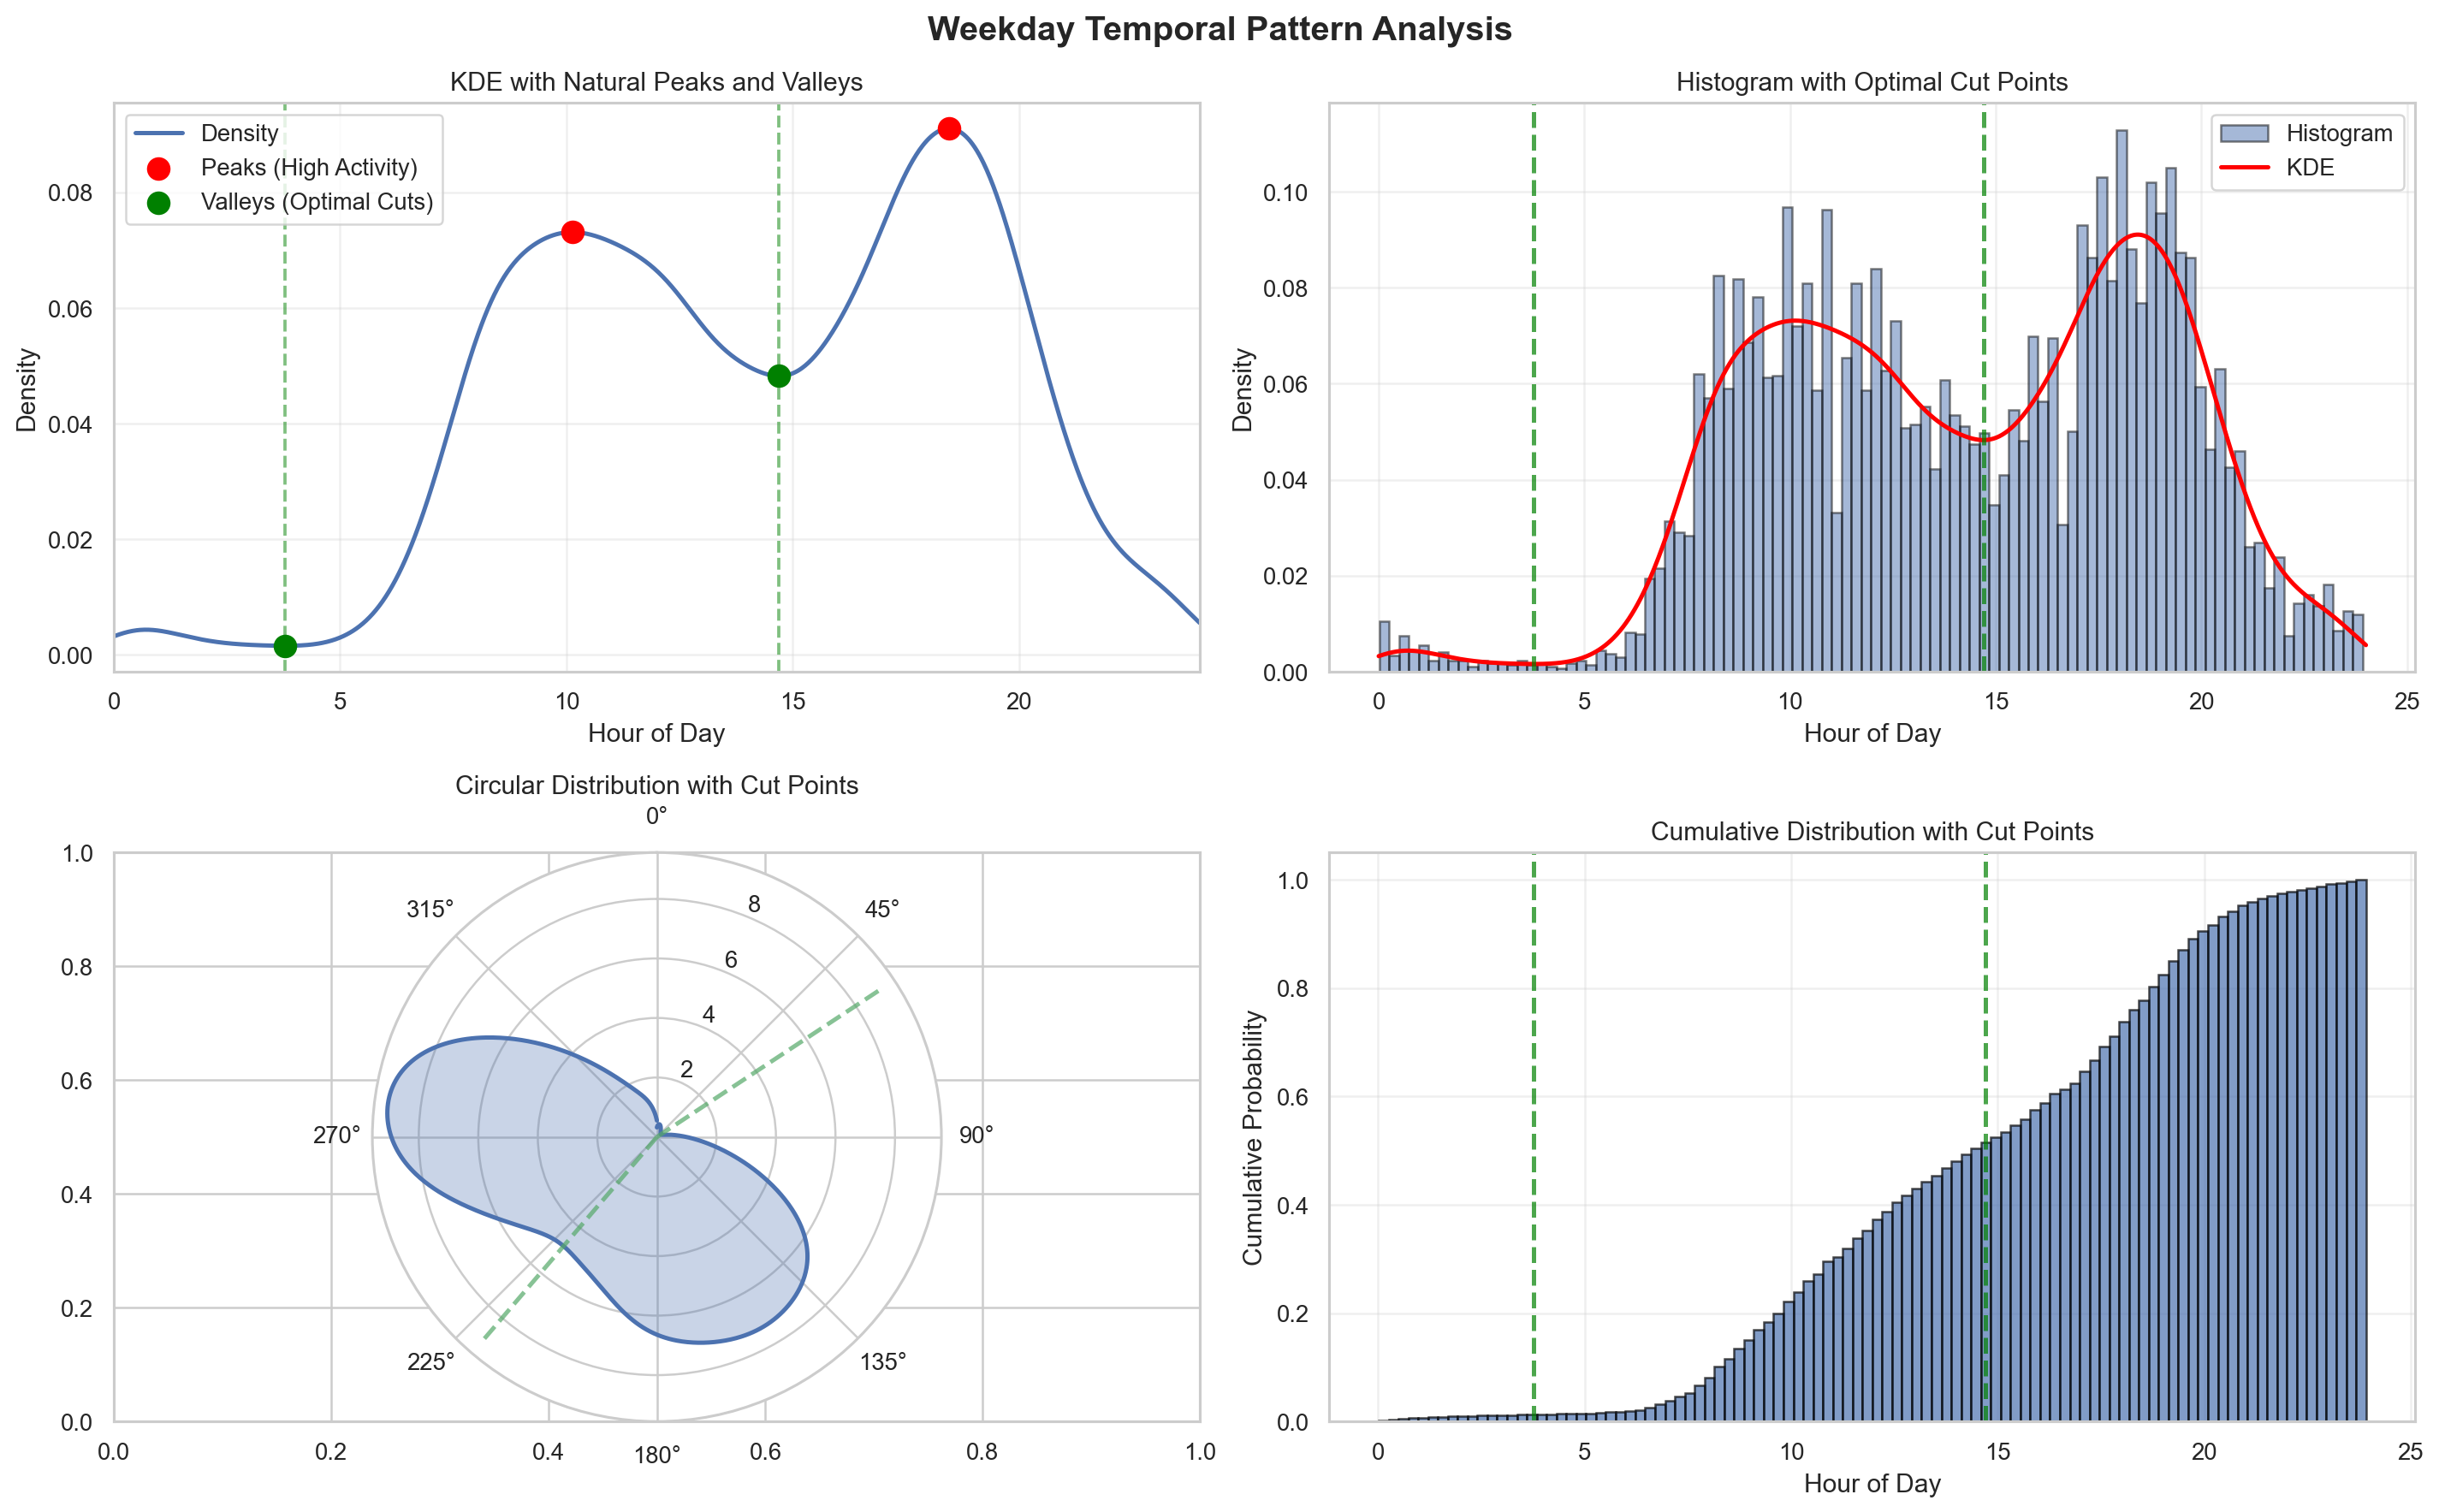


=== JENKS NATURAL BREAKS (Data-Driven Clustering) ===

4 bins: ['0.02h', '10.07h', '14.33h', '18.33h', '23.92h']
Breaks at: ['10:03', '14:19', '18:19']

5 bins: ['0.02h', '5.25h', '10.70h', '14.78h', '18.58h', '23.92h']
Breaks at: ['5:15', '10:41', '14:46', '18:34']

6 bins: ['0.02h', '5.00h', '10.08h', '13.33h', '16.58h', '19.55h', '23.92h']
Breaks at: ['5:00', '10:05', '13:19', '16:34', '19:32']

7 bins: ['0.02h', '4.83h', '9.42h', '12.03h', '14.92h', '17.58h', '20.08h', '23.92h']
Breaks at: ['4:49', '9:24', '12:01', '14:54', '17:34', '20:04']

=== GAUSSIAN MIXTURE MODEL (GMM) BIC Analysis ===
Finding optimal number of components...
Optimal number of components (lowest BIC): 9

GMM Cluster Centers (natural time groupings):
Cluster 1: 7.37h (7:22)
Cluster 2: 8.93h (8:55)
Cluster 3: 10.53h (10:31)
Cluster 4: 12.33h (12:19)
Cluster 5: 14.48h (14:29)
Cluster 6: 16.75h (16:45)
Cluster 7: 18.46h (18:27)
Cluster 8: 20.03h (20:01)
Cluster 9: 23.07h (23:04)


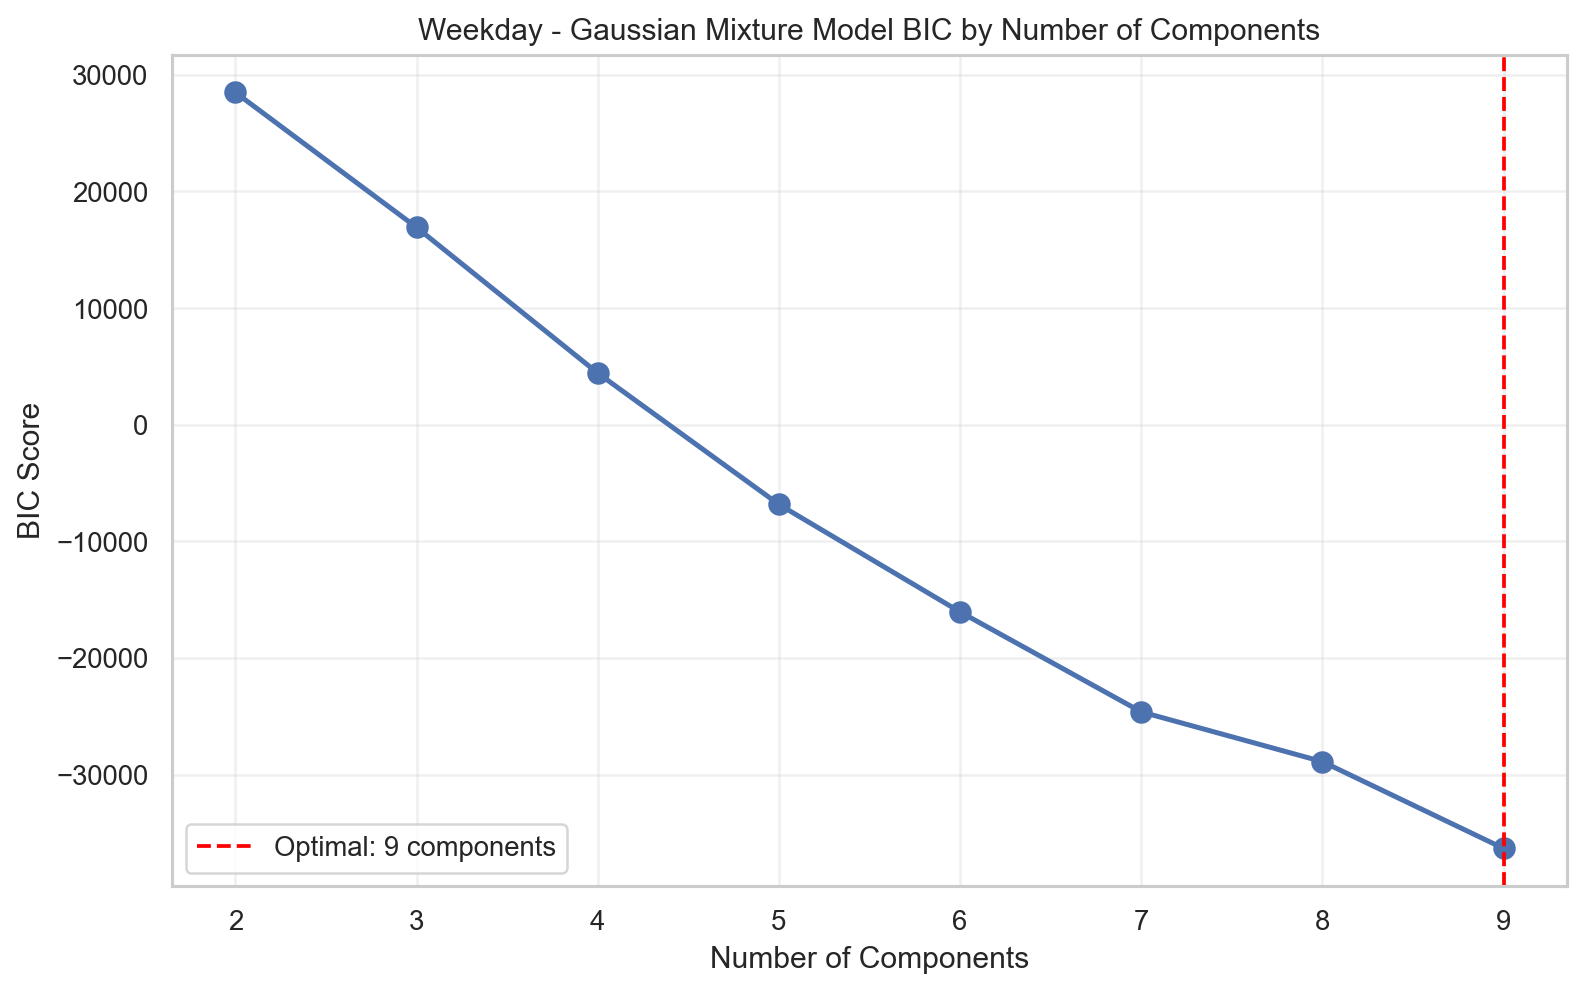


WEEKDAY - RECOMMENDED BINNING SCHEMES

2. GMM-Based Bins (Statistical Clustering - 9 bins):
   Cluster centers: ['7.37h', '8.93h', '10.53h', '12.33h', '14.48h', '16.75h', '18.46h', '20.03h', '23.07h']
   Suggested cut points: ['8.15h', '9.73h', '11.43h', '13.41h', '15.62h', '17.61h', '19.25h', '21.55h']

WEEKDAY - BIN BALANCE ANALYSIS

GMM-Based Bins:
  Bin edges: ['0.0', '8.1', '9.7', '11.4', '13.4', '15.6', '17.6', '19.2', '21.5', '24.0']
  Counts: [ 995 1370 1549 1517 1299 1675 1807 1635  421]
  Balance (std/mean): 0.313 (lower is better)
  Min/Max ratio: 0.233 (closer to 1 is better)

RECOMMENDATION: Choose bins with:
1. Low balance score (balanced category sizes)
2. Cut points at natural valleys (interpretable)
3. Alignment with domain knowledge (rush hours, etc.)

END OF WEEKDAY ANALYSIS



ANALYZING WEEKEND TEMPORAL PATTERNS

Total accidents in Weekend: 2,581

=== NATURAL PEAKS (High Accident Times) ===
Peak 1: 11.39h (11:23)
Peak 2: 18.76h (18:45)

=== NATURAL VALLEYS (Low Acc

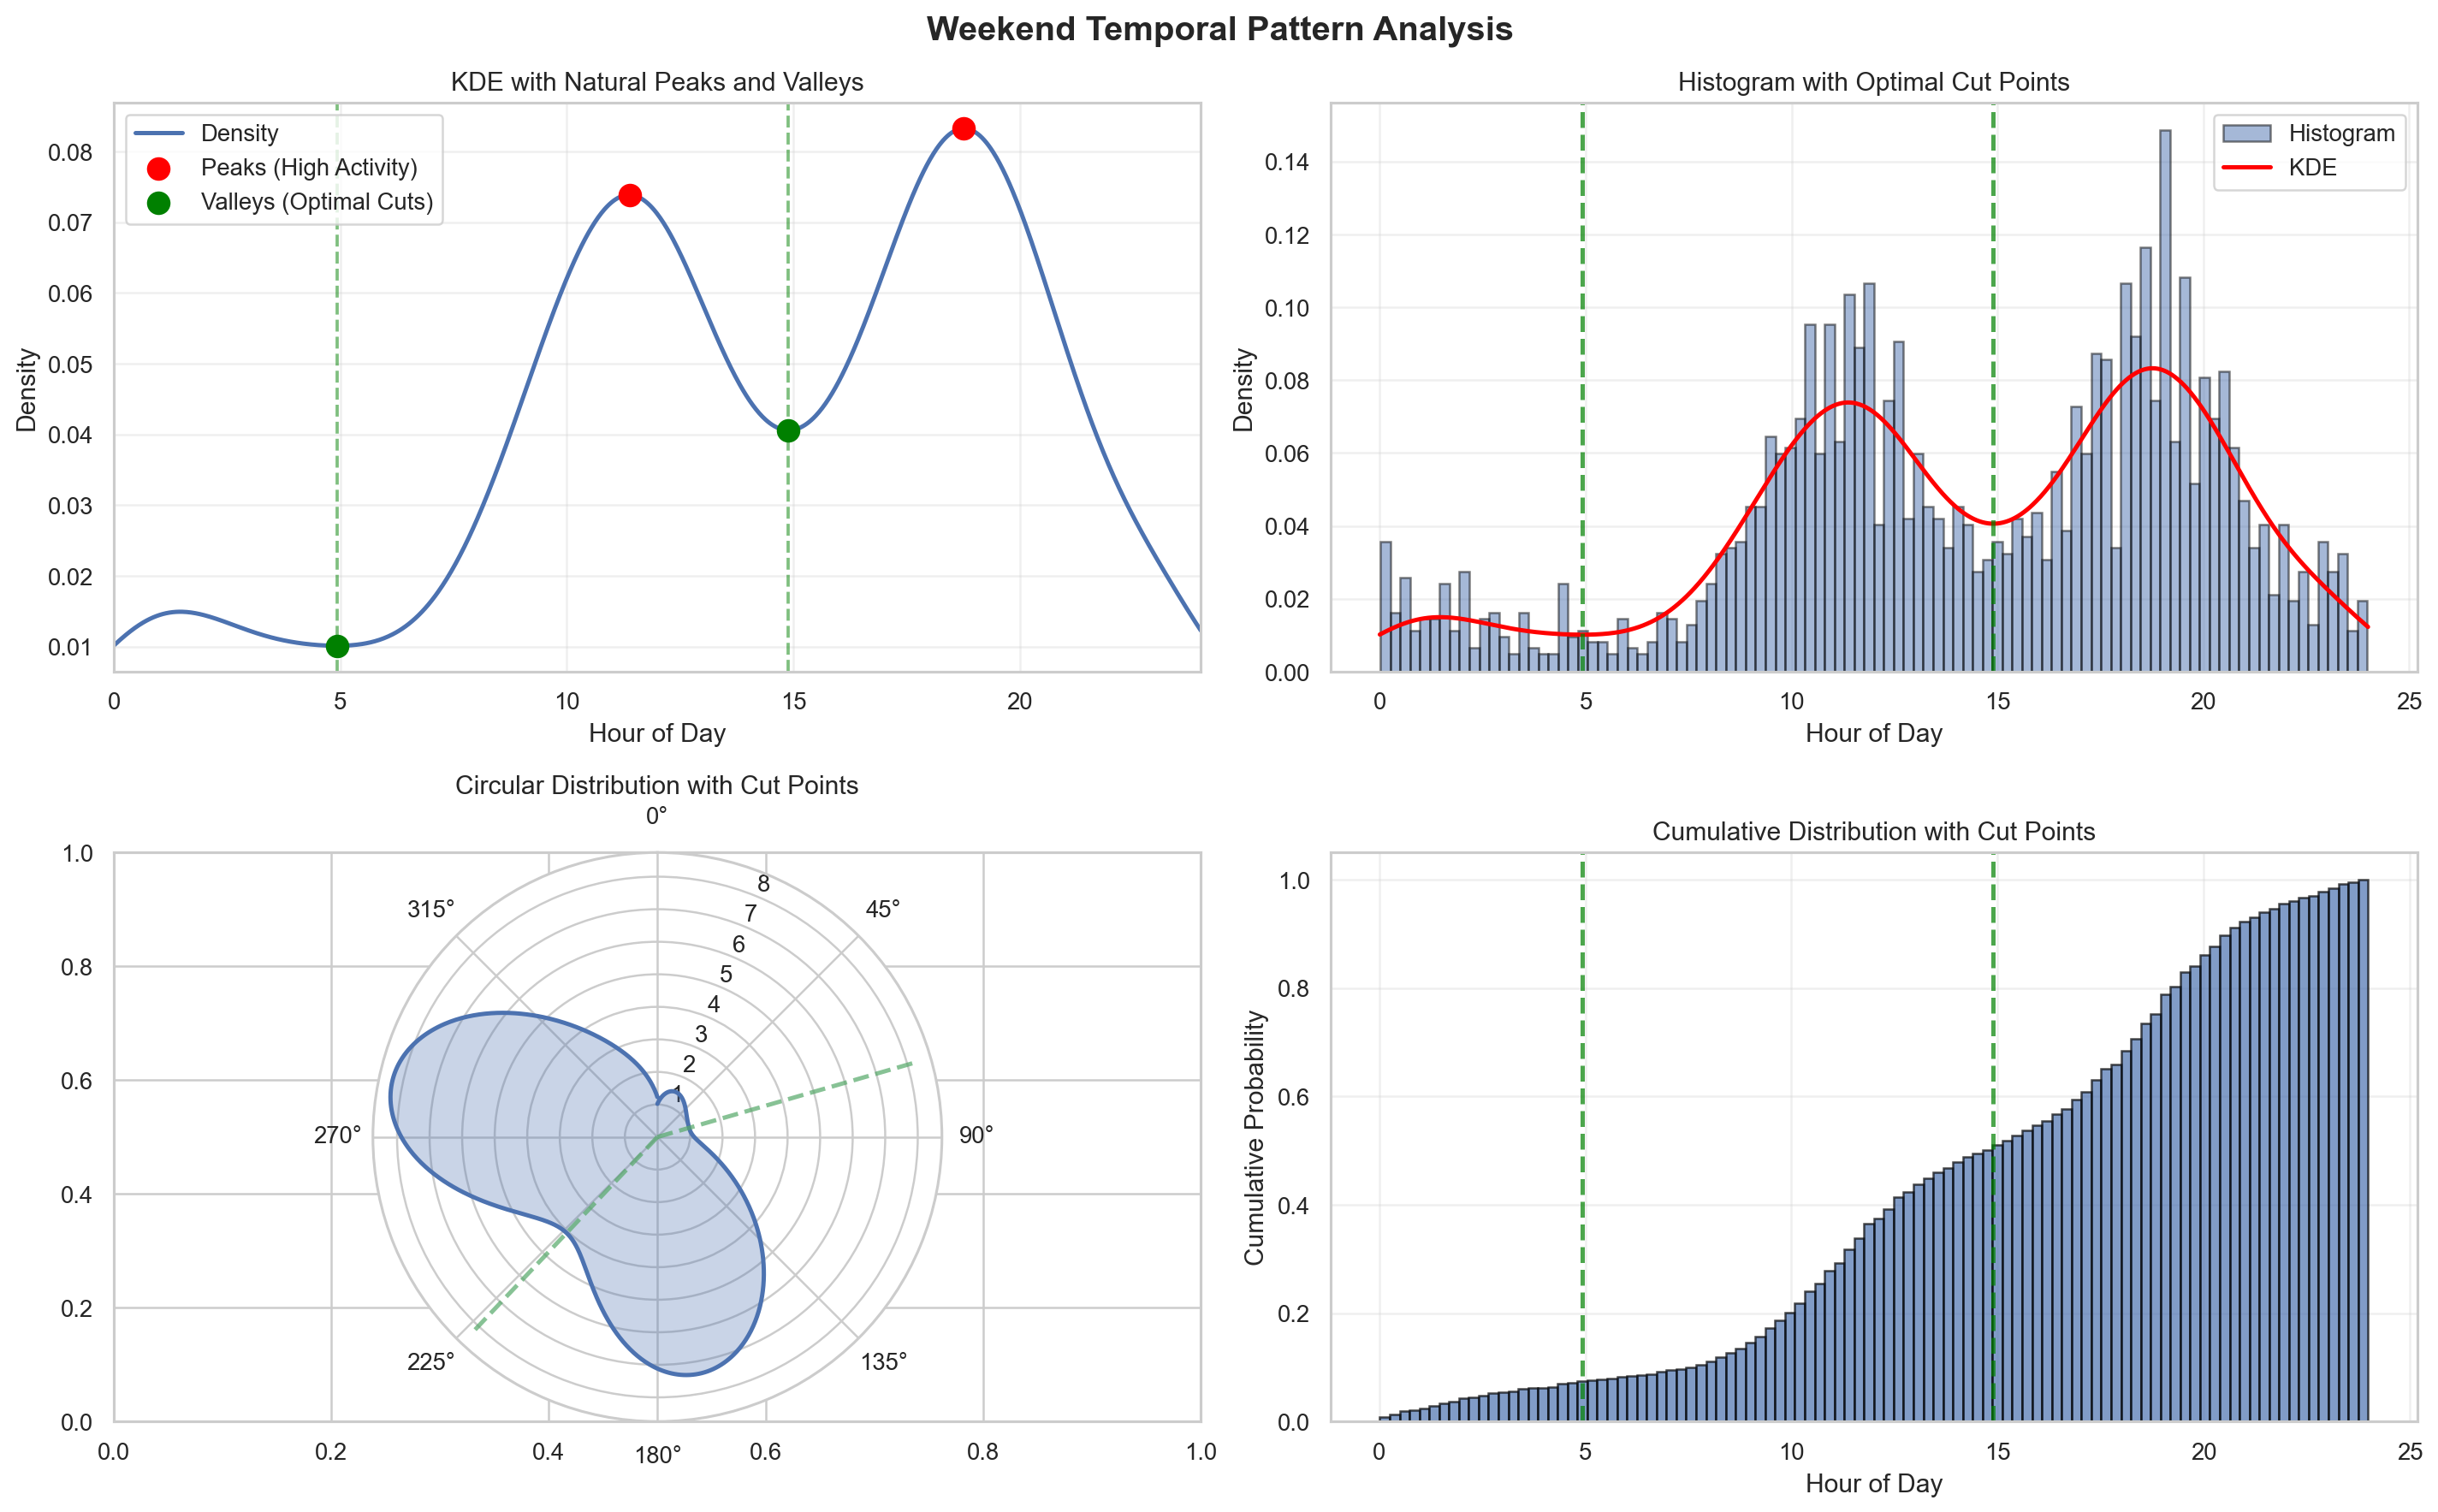


=== JENKS NATURAL BREAKS (Data-Driven Clustering) ===

4 bins: ['0.02h', '6.83h', '13.83h', '18.60h', '23.98h']
Breaks at: ['6:50', '13:49', '18:35']

5 bins: ['0.02h', '5.92h', '11.08h', '15.17h', '19.33h', '23.98h']
Breaks at: ['5:55', '11:05', '15:09', '19:19']

6 bins: ['0.02h', '5.67h', '10.50h', '13.75h', '17.08h', '20.08h', '23.98h']
Breaks at: ['5:40', '10:30', '13:44', '17:04', '20:04']

7 bins: ['0.02h', '4.75h', '9.17h', '11.83h', '14.83h', '17.92h', '20.58h', '23.98h']
Breaks at: ['4:45', '9:09', '11:50', '14:49', '17:55', '20:35']

=== GAUSSIAN MIXTURE MODEL (GMM) BIC Analysis ===
Finding optimal number of components...
Optimal number of components (lowest BIC): 9

GMM Cluster Centers (natural time groupings):
Cluster 1: 2.20h (2:11)
Cluster 2: 6.97h (6:58)
Cluster 3: 9.95h (9:56)
Cluster 4: 11.82h (11:49)
Cluster 5: 14.24h (14:14)
Cluster 6: 17.18h (17:10)
Cluster 7: 18.92h (18:55)
Cluster 8: 20.54h (20:32)
Cluster 9: 23.19h (23:11)


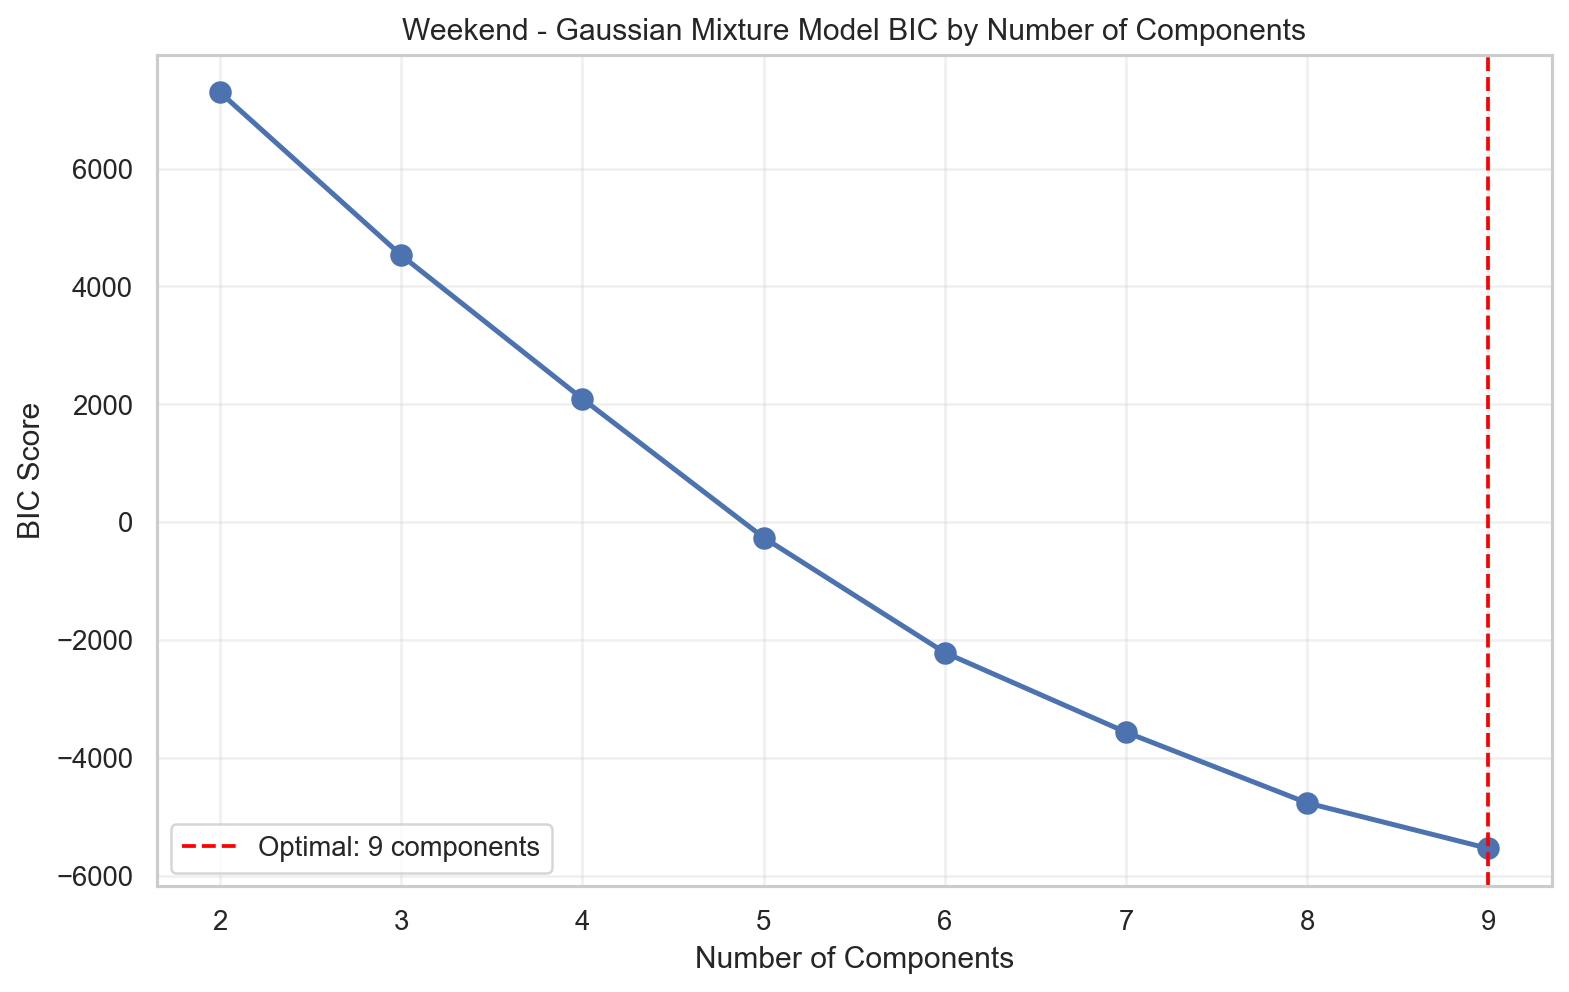


WEEKEND - RECOMMENDED BINNING SCHEMES

2. GMM-Based Bins (Statistical Clustering - 9 bins):
   Cluster centers: ['2.20h', '6.97h', '9.95h', '11.82h', '14.24h', '17.18h', '18.92h', '20.54h', '23.19h']
   Suggested cut points: ['4.59h', '8.46h', '10.88h', '13.03h', '15.71h', '18.05h', '19.73h', '21.87h']

WEEKEND - BIN BALANCE ANALYSIS

GMM-Based Bins:
  Bin edges: ['0.0', '4.6', '8.5', '10.9', '13.0', '15.7', '18.1', '19.7', '21.9', '24.0']
  Counts: [180 128 364 436 263 369 399 306 136]
  Balance (std/mean): 0.405 (lower is better)
  Min/Max ratio: 0.294 (closer to 1 is better)

RECOMMENDATION: Choose bins with:
1. Low balance score (balanced category sizes)
2. Cut points at natural valleys (interpretable)
3. Alignment with domain knowledge (rush hours, etc.)

END OF WEEKEND ANALYSIS




In [39]:
# =============================================================================
# TEMPORAL PATTERN ANALYSIS - SPLIT BY WEEKDAY/WEEKEND
# =============================================================================

# Loop through Weekday and Weekend separately
for day_type in ['Weekday', 'Weekend']:

    print("\n" + "="*80)
    print(f"ANALYZING {day_type.upper()} TEMPORAL PATTERNS")
    print("="*80 + "\n")

    # Subset data
    df_subset = df[df['DAY_BINARY'] == day_type].copy()
    print(f"Total accidents in {day_type}: {len(df_subset):,}")

    # Step 1: Analyze the continuous circular distribution
    df_subset['hour_continuous'] = np.arctan2(
        df_subset['time_sin'], df_subset['time_cos']) * 24 / (2 * np.pi)
    # Ensure 0-24 range
    df_subset['hour_continuous'] = df_subset['hour_continuous'] % 24

    # Step 2: Kernel Density Estimation to find natural peaks and valleys
    kde = gaussian_kde(df_subset['hour_continuous'], bw_method='scott')
    hours_grid = np.linspace(0, 24, 1000)
    density = kde(hours_grid)

    # Find peaks (high accident periods) and valleys (low accident periods)
    peaks, peak_properties = find_peaks(density, prominence=0.01)
    valleys_idx = argrelextrema(density, np.less, order=20)[0]

    peak_hours = hours_grid[peaks]
    valley_hours = hours_grid[valleys_idx]

    print(f"\n=== NATURAL PEAKS (High Accident Times) ===")
    for i, peak_hour in enumerate(peak_hours):
        print(
            f"Peak {i+1}: {peak_hour:.2f}h ({int(peak_hour)}:{int((peak_hour % 1)*60):02d})")

    print(f"\n=== NATURAL VALLEYS (Low Accident Times - Optimal Cut Points) ===")
    for i, valley_hour in enumerate(valley_hours):
        print(
            f"Valley {i+1}: {valley_hour:.2f}h ({int(valley_hour)}:{int((valley_hour % 1)*60):02d})")

    # Step 3: Visualize KDE with peaks and valleys
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{day_type} Temporal Pattern Analysis',
                 fontsize=16, fontweight='bold')

    # KDE with marked peaks and valleys
    axes[0, 0].plot(hours_grid, density, linewidth=2, label='Density')
    axes[0, 0].scatter(peak_hours, density[peaks], color='red', s=100,
                       zorder=5, label='Peaks (High Activity)')
    axes[0, 0].scatter(valley_hours, density[valleys_idx], color='green', s=100,
                       zorder=5, label='Valleys (Optimal Cuts)')
    for valley in valley_hours:
        axes[0, 0].axvline(valley, color='green', linestyle='--', alpha=0.5)
    axes[0, 0].set_xlabel('Hour of Day')
    axes[0, 0].set_ylabel('Density')
    axes[0, 0].set_title('KDE with Natural Peaks and Valleys')
    axes[0, 0].legend()
    axes[0, 0].set_xlim(0, 24)
    axes[0, 0].grid(True, alpha=0.3)

    # Histogram overlay
    axes[0, 1].hist(df_subset['hour_continuous'], bins=100, density=True,
                    alpha=0.5, edgecolor='black', label='Histogram')
    axes[0, 1].plot(hours_grid, density, linewidth=2, color='red', label='KDE')
    for valley in valley_hours:
        axes[0, 1].axvline(valley, color='green',
                           linestyle='--', alpha=0.7, linewidth=2)
    axes[0, 1].set_xlabel('Hour of Day')
    axes[0, 1].set_ylabel('Density')
    axes[0, 1].set_title('Histogram with Optimal Cut Points')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Step 4: Circular histogram (polar plot)
    ax_polar = plt.subplot(2, 2, 3, projection='polar')
    theta = np.linspace(0, 2*np.pi, len(density))
    ax_polar.plot(theta, density * 100, linewidth=2)  # Scale for visibility
    ax_polar.fill(theta, density * 100, alpha=0.3)
    # Mark valleys on polar plot
    for valley in valley_hours:
        valley_theta = valley * 2 * np.pi / 24
        ax_polar.plot([valley_theta, valley_theta], [0, max(density)*100],
                      'g--', linewidth=2, alpha=0.7)
    ax_polar.set_theta_zero_location('N')
    ax_polar.set_theta_direction(-1)
    ax_polar.set_title('Circular Distribution with Cut Points')

    # Step 5: Cumulative distribution to ensure balanced bins
    axes[1, 1].hist(df_subset['hour_continuous'], bins=100, cumulative=True,
                    density=True, alpha=0.7, edgecolor='black')
    for valley in valley_hours:
        axes[1, 1].axvline(valley, color='green',
                           linestyle='--', linewidth=2, alpha=0.7)
    axes[1, 1].set_xlabel('Hour of Day')
    axes[1, 1].set_ylabel('Cumulative Probability')
    axes[1, 1].set_title('Cumulative Distribution with Cut Points')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        f'temporal_analysis_{day_type.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Step 6: Jenks Natural Breaks Optimization
    print(f"\n=== JENKS NATURAL BREAKS (Data-Driven Clustering) ===")
    try:
        from jenkspy import jenks_breaks

        for n_bins in [4, 5, 6, 7]:
            breaks = jenks_breaks(
                df_subset['hour_continuous'].values, n_classes=n_bins)
            print(f"\n{n_bins} bins: {[f'{b:.2f}h' for b in breaks]}")
            print(
                f"Breaks at: {[f'{int(b)}:{int((b % 1)*60):02d}' for b in breaks[1:-1]]}")

    except ImportError:
        print("\nInstall jenkspy for Jenks optimization: pip install jenkspy")

    # Step 7: Bayesian Information Criterion (BIC) for Gaussian Mixture Models
    print(f"\n=== GAUSSIAN MIXTURE MODEL (GMM) BIC Analysis ===")
    print("Finding optimal number of components...")

    # Reshape time as circular features for GMM
    X_circular = df_subset[['time_sin', 'time_cos']].values

    bic_scores = []
    n_components_range = range(2, 10)

    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, random_state=42)
        gmm.fit(X_circular)
        bic_scores.append(gmm.bic(X_circular))

    optimal_n = n_components_range[np.argmin(bic_scores)]
    print(f"Optimal number of components (lowest BIC): {optimal_n}")

    # Fit optimal GMM and find cluster centers
    gmm_optimal = GaussianMixture(n_components=optimal_n, random_state=42)
    gmm_optimal.fit(X_circular)

    # Convert cluster centers back to hours
    cluster_centers_hours = np.arctan2(gmm_optimal.means_[:, 0],
                                       gmm_optimal.means_[:, 1]) * 24 / (2 * np.pi)
    cluster_centers_hours = cluster_centers_hours % 24
    cluster_centers_hours = np.sort(cluster_centers_hours)

    print(f"\nGMM Cluster Centers (natural time groupings):")
    for i, center in enumerate(cluster_centers_hours):
        print(
            f"Cluster {i+1}: {center:.2f}h ({int(center)}:{int((center % 1)*60):02d})")

    # Plot BIC scores
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.plot(n_components_range, bic_scores,
            marker='o', linewidth=2, markersize=8)
    ax.axvline(optimal_n, color='red', linestyle='--',
               label=f'Optimal: {optimal_n} components')
    ax.set_xlabel('Number of Components')
    ax.set_ylabel('BIC Score')
    ax.set_title(
        f'{day_type} - Gaussian Mixture Model BIC by Number of Components')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.savefig(f'gmm_bic_{day_type.lower()}.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    # Step 8: Create candidate binning schemes based on statistical findings
    print("\n" + "="*80)
    print(f"{day_type.upper()} - RECOMMENDED BINNING SCHEMES")
    print("="*80)

    # Sort valleys for clean bin edges
    valley_hours_sorted = np.sort(valley_hours)

    if len(valley_hours_sorted) >= 4:
        print("\n1. KDE Valley-Based Bins (Natural Low Points):")
        print(
            f"   Cut points: {[f'{v:.2f}h ({int(v)}:{int((v % 1)*60):02d})' for v in valley_hours_sorted[:5]]}")
        print(
            f"   Bins: 0 -> {' -> '.join([f'{v:.1f}' for v in valley_hours_sorted[:5]])} -> 24")

    print(f"\n2. GMM-Based Bins (Statistical Clustering - {optimal_n} bins):")
    print(
        f"   Cluster centers: {[f'{c:.2f}h' for c in cluster_centers_hours]}")
    # Create bin edges midway between cluster centers
    if len(cluster_centers_hours) > 1:
        gmm_bin_edges = [0]
        for i in range(len(cluster_centers_hours) - 1):
            midpoint = (
                cluster_centers_hours[i] + cluster_centers_hours[i+1]) / 2
            gmm_bin_edges.append(midpoint)
        gmm_bin_edges.append(24)
        print(
            f"   Suggested cut points: {[f'{e:.2f}h' for e in gmm_bin_edges[1:-1]]}")

    # Step 9: Compare bin balance for top candidates
    print("\n" + "="*80)
    print(f"{day_type.upper()} - BIN BALANCE ANALYSIS")
    print("="*80)

    def evaluate_bins(bin_edges, name, data):
        """Evaluate how balanced a binning scheme is"""
        bins_labeled = pd.cut(data['hour_continuous'],
                              bins=bin_edges, include_lowest=True)
        counts = bins_labeled.value_counts().sort_index()

        print(f"\n{name}:")
        print(f"  Bin edges: {[f'{e:.1f}' for e in bin_edges]}")
        print(f"  Counts: {counts.values}")
        print(
            f"  Balance (std/mean): {counts.std()/counts.mean():.3f} (lower is better)")
        print(
            f"  Min/Max ratio: {counts.min()/counts.max():.3f} (closer to 1 is better)")

        return bins_labeled, counts

    # Test valley-based bins
    if len(valley_hours_sorted) >= 3:
        valley_bins = [0] + list(valley_hours_sorted[:4]) + [24]
        _, _ = evaluate_bins(valley_bins, "Valley-Based Bins", df_subset)

    # Test GMM bins
    if len(gmm_bin_edges) > 2:
        _, _ = evaluate_bins(gmm_bin_edges, "GMM-Based Bins", df_subset)

    print("\n" + "="*80)
    print("RECOMMENDATION: Choose bins with:")
    print("1. Low balance score (balanced category sizes)")
    print("2. Cut points at natural valleys (interpretable)")
    print("3. Alignment with domain knowledge (rush hours, etc.)")
    print("="*80)

    print(f"\n{'='*80}")
    print(f"END OF {day_type.upper()} ANALYSIS")
    print(f"{'='*80}\n\n")


WEEKDAY - JENKS NATURAL BREAKS BIN BALANCE ANALYSIS
Total accidents in Weekday: 12,268

4-BIN
  Breaks: ['0.02h (0:01)', '10.07h (10:03)', '14.33h (14:19)', '18.33h (18:19)', '23.92h (23:55)']

  Distribution:
    Bin_1:  2727 ( 22.2%)
    Bin_2:  3313 ( 27.0%)
    Bin_3:  3239 ( 26.4%)
    Bin_4:  2989 ( 24.4%)

  Balance (std/mean): 0.087 (lower = better)
  Min/Max ratio: 0.823 (closer to 1 = better)
  Range: 2727 - 3313

5-BIN
  Breaks: ['0.02h (0:01)', '5.25h (5:15)', '10.70h (10:41)', '14.78h (14:46)', '18.58h (18:34)', '23.92h (23:55)']

  Distribution:
    Bin_1:   186 (  1.5%)
    Bin_2:  3093 ( 25.2%)
    Bin_3:  3002 ( 24.5%)
    Bin_4:  3259 ( 26.6%)
    Bin_5:  2728 ( 22.2%)

  Balance (std/mean): 0.523 (lower = better)
  Min/Max ratio: 0.057 (closer to 1 = better)
  Range: 186 - 3259

6-BIN
  Breaks: ['0.02h (0:01)', '5.00h (5:00)', '10.08h (10:05)', '13.33h (13:19)', '16.58h (16:34)', '19.55h (19:32)', '23.92h (23:55)']

  Distribution:
    Bin_1:   182 (  1.5%)
    Bin_

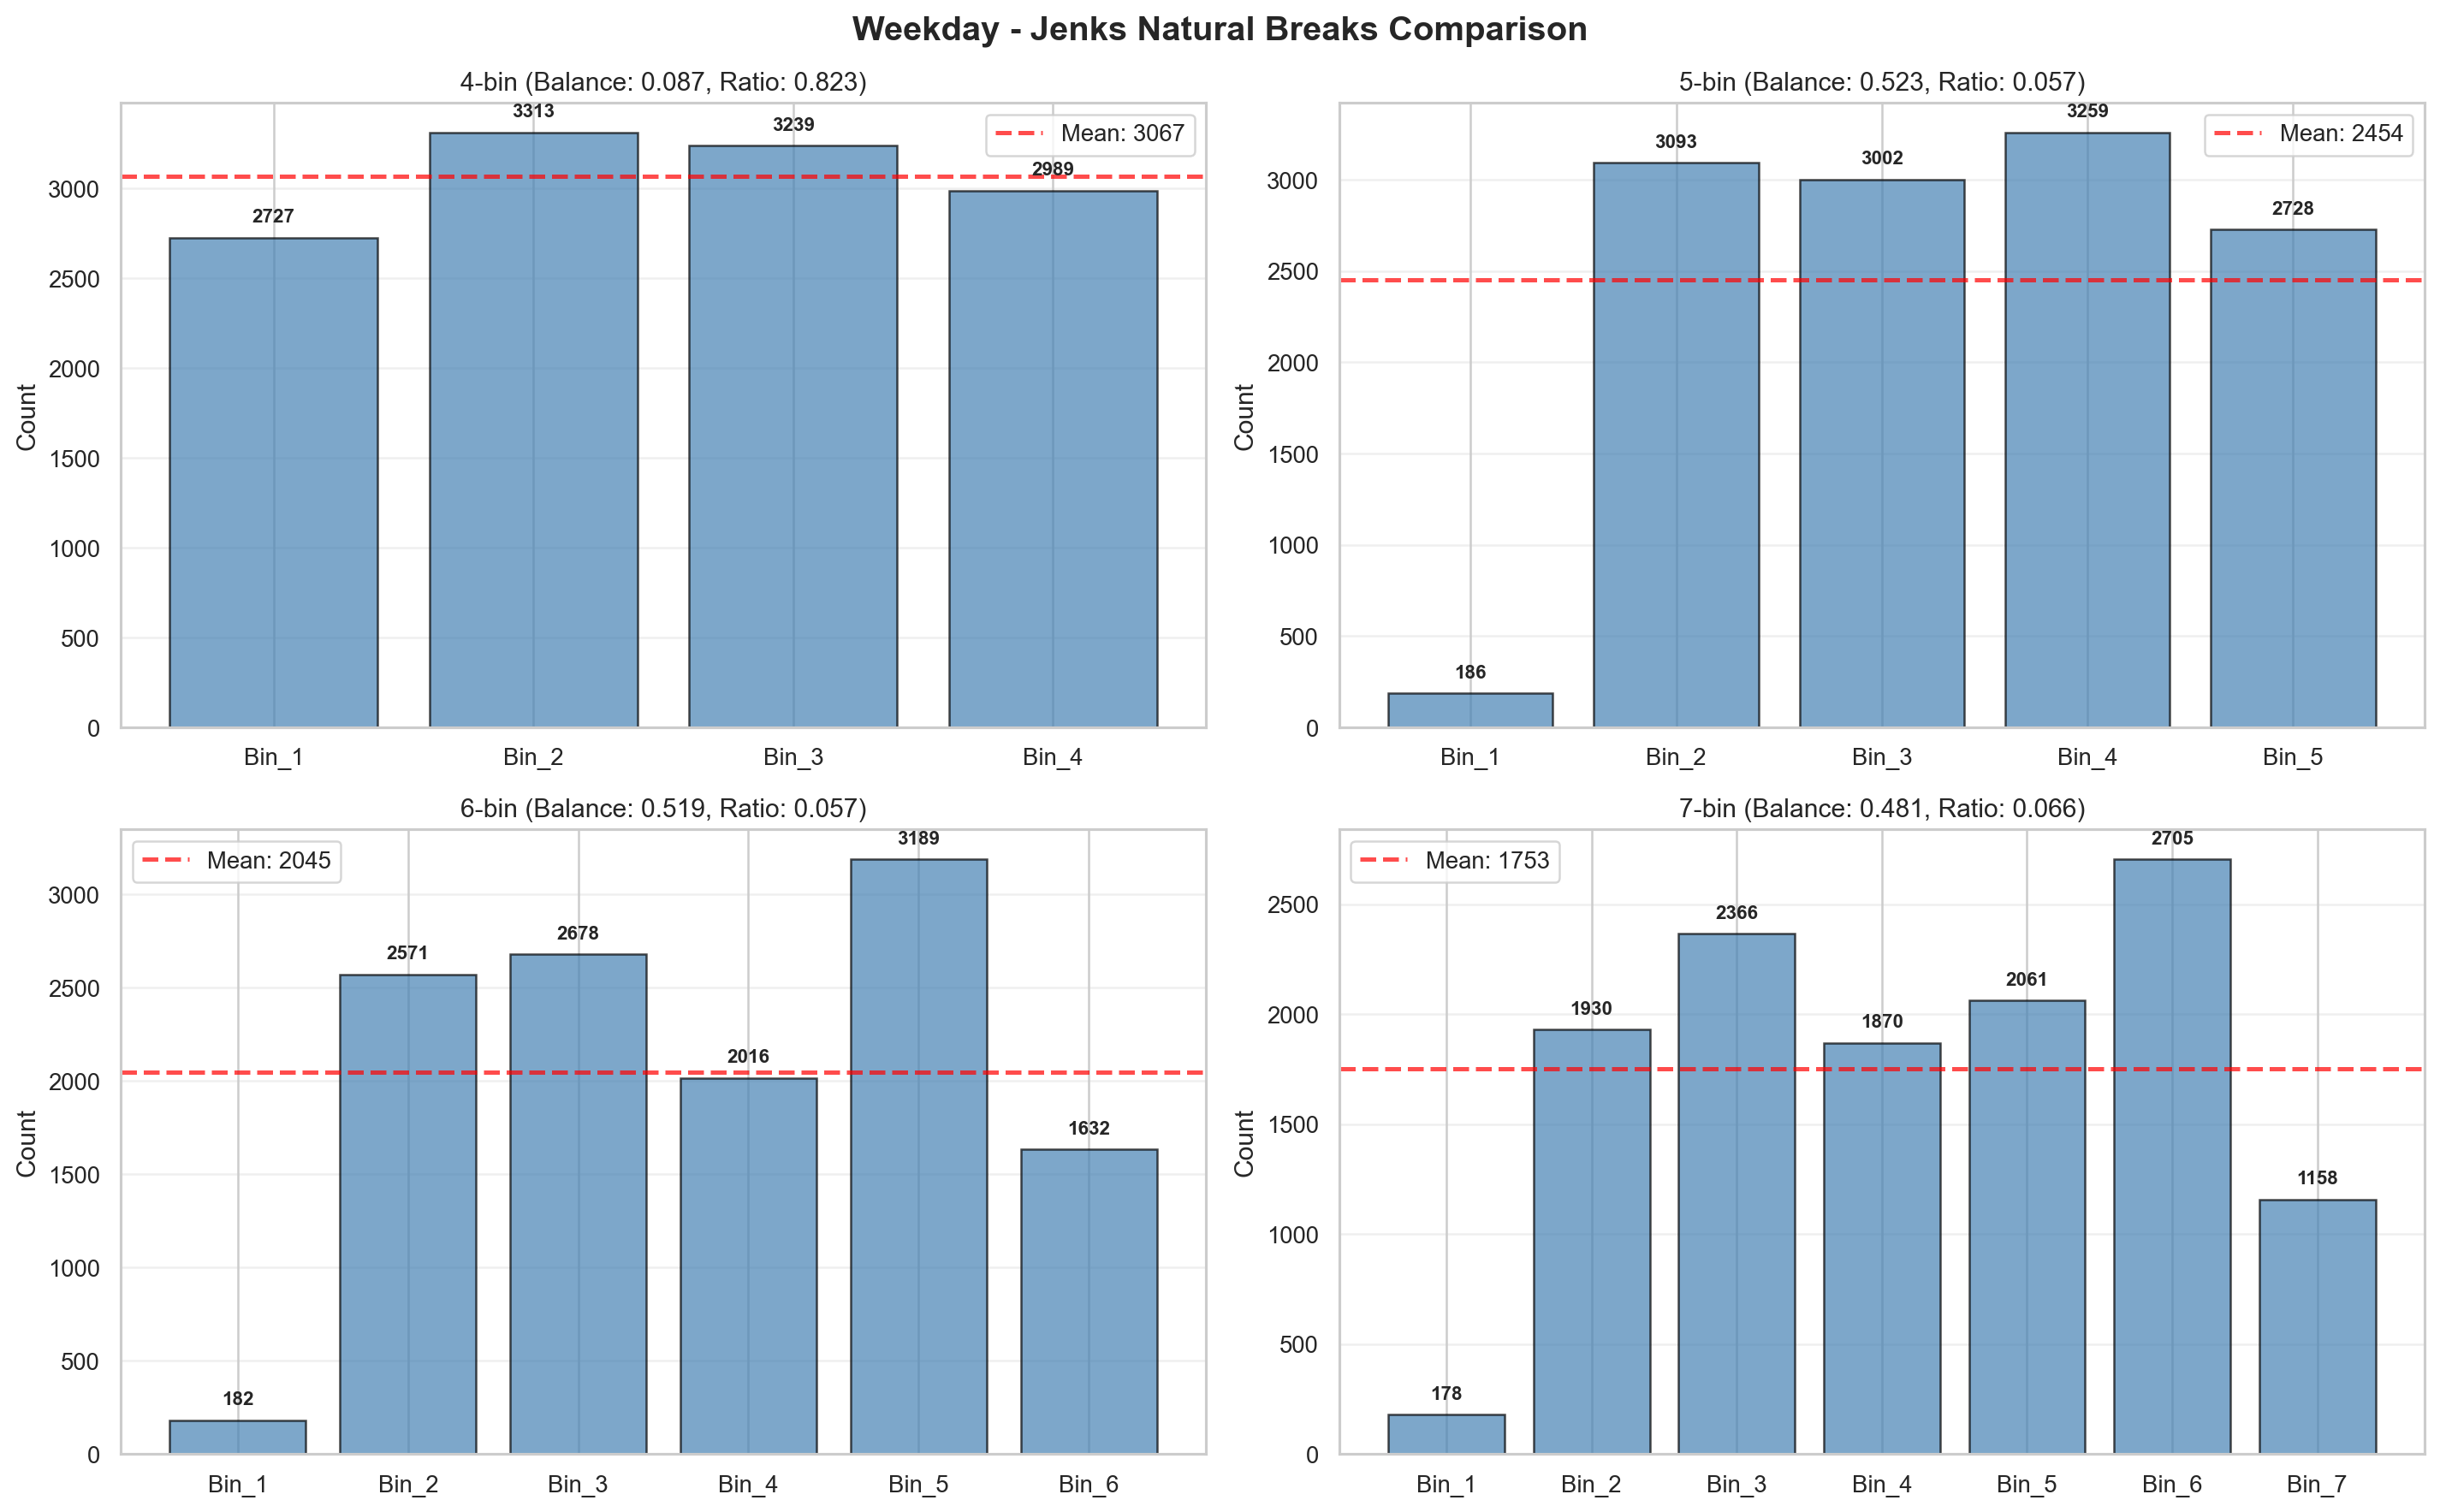


WEEKDAY - BIN TIME RANGES (Human Readable)

4-BIN:
  Bin 1: 00:01 - 10:03  →   2727 accidents ( 22.2%)
  Bin 2: 10:03 - 14:19  →   3313 accidents ( 27.0%)
  Bin 3: 14:19 - 18:19  →   3239 accidents ( 26.4%)
  Bin 4: 18:19 - 23:55  →   2989 accidents ( 24.4%)

5-BIN:
  Bin 1: 00:01 - 05:15  →    186 accidents (  1.5%)
  Bin 2: 05:15 - 10:41  →   3093 accidents ( 25.2%)
  Bin 3: 10:41 - 14:46  →   3002 accidents ( 24.5%)
  Bin 4: 14:46 - 18:34  →   3259 accidents ( 26.6%)
  Bin 5: 18:34 - 23:55  →   2728 accidents ( 22.2%)

6-BIN:
  Bin 1: 00:01 - 05:00  →    182 accidents (  1.5%)
  Bin 2: 05:00 - 10:05  →   2571 accidents ( 21.0%)
  Bin 3: 10:05 - 13:19  →   2678 accidents ( 21.8%)
  Bin 4: 13:19 - 16:34  →   2016 accidents ( 16.4%)
  Bin 5: 16:34 - 19:32  →   3189 accidents ( 26.0%)
  Bin 6: 19:32 - 23:55  →   1632 accidents ( 13.3%)

7-BIN:
  Bin 1: 00:01 - 04:49  →    178 accidents (  1.5%)
  Bin 2: 04:49 - 09:24  →   1930 accidents ( 15.7%)
  Bin 3: 09:24 - 12:01  →   2366 acciden

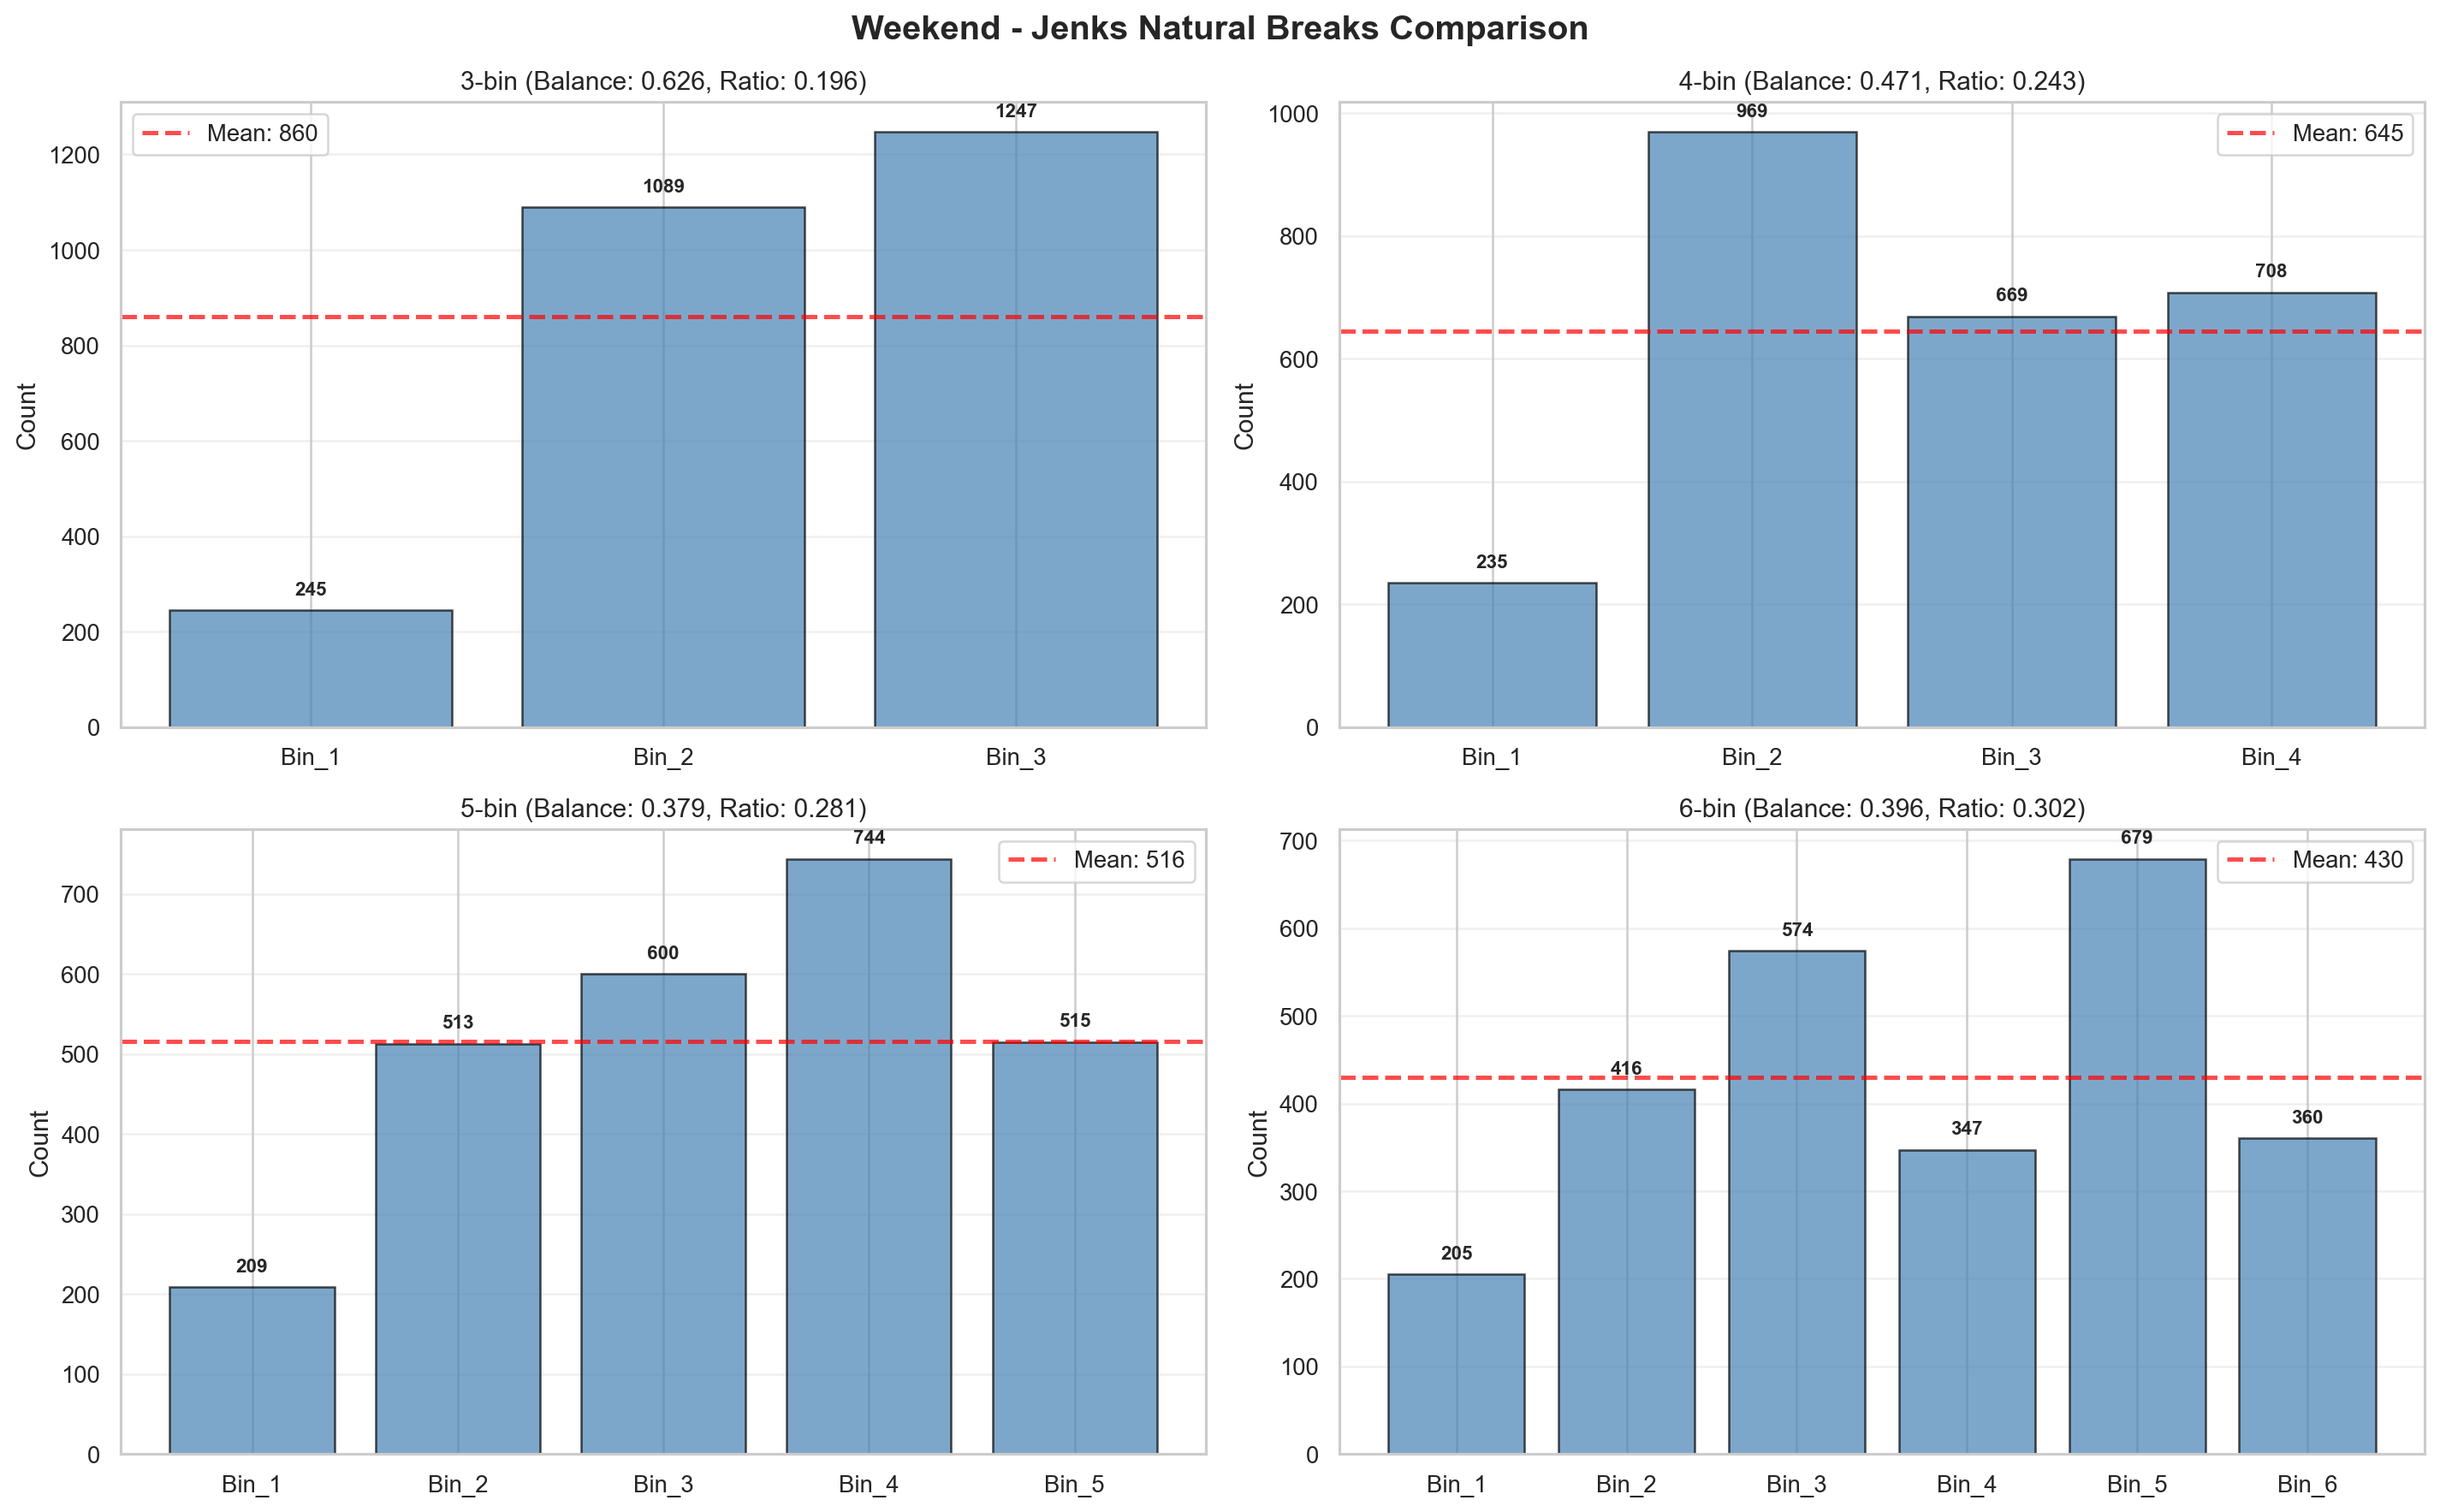


WEEKEND - BIN TIME RANGES (Human Readable)

3-BIN:
  Bin 1: 00:01 - 07:09  →    245 accidents (  9.5%)
  Bin 2: 07:09 - 15:14  →   1089 accidents ( 42.2%)
  Bin 3: 15:14 - 23:59  →   1247 accidents ( 48.3%)

4-BIN:
  Bin 1: 00:01 - 06:50  →    235 accidents (  9.1%)
  Bin 2: 06:50 - 13:49  →    969 accidents ( 37.5%)
  Bin 3: 13:49 - 18:35  →    669 accidents ( 25.9%)
  Bin 4: 18:35 - 23:59  →    708 accidents ( 27.4%)

5-BIN:
  Bin 1: 00:01 - 05:55  →    209 accidents (  8.1%)
  Bin 2: 05:55 - 11:05  →    513 accidents ( 19.9%)
  Bin 3: 11:05 - 15:09  →    600 accidents ( 23.2%)
  Bin 4: 15:09 - 19:19  →    744 accidents ( 28.8%)
  Bin 5: 19:19 - 23:59  →    515 accidents ( 20.0%)

6-BIN:
  Bin 1: 00:01 - 05:40  →    205 accidents (  7.9%)
  Bin 2: 05:40 - 10:30  →    416 accidents ( 16.1%)
  Bin 3: 10:30 - 13:44  →    574 accidents ( 22.2%)
  Bin 4: 13:44 - 17:04  →    347 accidents ( 13.4%)
  Bin 5: 17:04 - 20:04  →    679 accidents ( 26.3%)
  Bin 6: 20:04 - 23:59  →    360 acciden

In [40]:
# =============================================================================
# JENKS NATURAL BREAKS - WEEKDAY/WEEKEND SPECIFIC ANALYSIS
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from jenkspy import jenks_breaks

# Loop through Weekday and Weekend
for day_type in ['Weekday', 'Weekend']:

    print("\n" + "="*80)
    print(f"{day_type.upper()} - JENKS NATURAL BREAKS BIN BALANCE ANALYSIS")
    print("="*80)

    # Subset data
    df_subset = df[df['DAY_BINARY'] == day_type].copy()

    # CREATE hour_continuous from circular time features
    df_subset['hour_continuous'] = np.arctan2(
        df_subset['time_sin'], df_subset['time_cos']) * 24 / (2 * np.pi)
    # Ensure 0-24 range
    df_subset['hour_continuous'] = df_subset['hour_continuous'] % 24

    print(f"Total accidents in {day_type}: {len(df_subset):,}")

    # Define appropriate bin ranges for each day type
    if day_type == 'Weekday':
        # More granular for complex commute patterns
        bin_options = [4, 5, 6, 7]
    else:  # Weekend
        bin_options = [3, 4, 5, 6]  # Simpler for leisure patterns

    jenks_schemes = {}

    # Generate Jenks breaks for each bin count
    for n_bins in bin_options:
        breaks = jenks_breaks(
            df_subset['hour_continuous'].values, n_classes=n_bins)
        jenks_schemes[f'{n_bins}-bin'] = breaks

    results = {}

    for name, breaks in jenks_schemes.items():
        # Create bins
        n_bins = int(name.split('-')[0])
        labels = [f'Bin_{i+1}' for i in range(n_bins)]

        df_subset[f'jenks_{name}'] = pd.cut(
            df_subset['hour_continuous'],
            bins=breaks,
            labels=labels,
            include_lowest=True
        )

        # Get counts
        counts = df_subset[f'jenks_{name}'].value_counts().sort_index()

        # Calculate balance metrics
        balance_score = counts.std() / counts.mean()
        min_max_ratio = counts.min() / counts.max()

        results[name] = {
            'breaks': breaks,
            'counts': counts,
            'balance': balance_score,
            'ratio': min_max_ratio
        }

        # Print results
        print(f"\n{name.upper()}")
        print(
            f"  Breaks: {[f'{b:.2f}h ({int(b)}:{int((b % 1)*60):02d})' for b in breaks]}")
        print(f"\n  Distribution:")
        for label, count in counts.items():
            pct = count / len(df_subset) * 100
            print(f"    {label}: {count:>5} ({pct:>5.1f}%)")

        print(f"\n  Balance (std/mean): {balance_score:.3f} (lower = better)")
        print(f"  Min/Max ratio: {min_max_ratio:.3f} (closer to 1 = better)")
        print(f"  Range: {counts.min()} - {counts.max()}")

    # Compare all schemes side by side
    print("\n" + "="*80)
    print(f"{day_type.upper()} - SUMMARY COMPARISON")
    print("="*80)
    print(f"{'Scheme':<15} {'Balance':<12} {'Min/Max':<12} {'Min Count':<12} {'Max Count':<12}")
    print("-"*80)
    for name, data in results.items():
        print(f"{name:<15} {data['balance']:<12.3f} {data['ratio']:<12.3f} "
              f"{data['counts'].min():<12} {data['counts'].max():<12}")

    # Find best scheme
    best_balance = min(results.items(), key=lambda x: x[1]['balance'])
    best_ratio = max(results.items(), key=lambda x: x[1]['ratio'])

    print(
        f"\n🏆 Best Balance: {best_balance[0]} (score: {best_balance[1]['balance']:.3f})")
    print(
        f"🏆 Best Ratio: {best_ratio[0]} (ratio: {best_ratio[1]['ratio']:.3f})")

    # Visualize all schemes
    n_schemes = len(results)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{day_type} - Jenks Natural Breaks Comparison',
                 fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for idx, (name, data) in enumerate(results.items()):
        if idx < len(axes):
            counts = data['counts']

            # Bar plot
            axes[idx].bar(range(len(counts)), counts.values,
                          color='steelblue', edgecolor='black', alpha=0.7)
            axes[idx].set_xticks(range(len(counts)))
            axes[idx].set_xticklabels(counts.index, rotation=0)
            axes[idx].set_ylabel('Count')
            axes[idx].set_title(
                f'{name} (Balance: {data["balance"]:.3f}, Ratio: {data["ratio"]:.3f})')
            axes[idx].grid(axis='y', alpha=0.3)

            # Add mean line
            axes[idx].axhline(counts.mean(), color='red', linestyle='--',
                              alpha=0.7, linewidth=2, label=f'Mean: {counts.mean():.0f}')

            # Add count labels on bars
            for i, (label, count) in enumerate(counts.items()):
                axes[idx].text(i, count + max(counts.values)*0.02, str(count),
                               ha='center', va='bottom', fontsize=9, fontweight='bold')

            axes[idx].legend()

    # Hide unused subplots
    for idx in range(len(results), len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig(
        f'jenks_comparison_{day_type.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Show time ranges for each bin
    print("\n" + "="*80)
    print(f"{day_type.upper()} - BIN TIME RANGES (Human Readable)")
    print("="*80)

    for name, data in results.items():
        breaks = data['breaks']
        print(f"\n{name.upper()}:")
        for i in range(len(breaks)-1):
            start_h = int(breaks[i])
            start_m = int((breaks[i] % 1) * 60)
            end_h = int(breaks[i+1])
            end_m = int((breaks[i+1] % 1) * 60)

            count = data['counts'].iloc[i]
            pct = count / len(df_subset) * 100

            print(f"  Bin {i+1}: {start_h:02d}:{start_m:02d} - {end_h:02d}:{end_m:02d}  "
                  f"→  {count:>5} accidents ({pct:>5.1f}%)")

    print("\n" + "="*80)
    print("RECOMMENDATION: Look for the scheme with:")
    print("  - Balance score < 0.4 (good distribution)")
    print("  - Min/Max ratio > 0.5 (no bin too small/large)")
    print("  - Interpretable time ranges (matches domain knowledge)")
    print("="*80)

    print(f"\n{'='*80}")
    print(f"END OF {day_type.upper()} JENKS ANALYSIS")
    print(f"{'='*80}\n\n")

## Critical Analysis of Jenks Results

### **WEEKDAY: 6-Bin is Optimal**

**Why not the others:**
- **4-bin**: Too coarse (loses important rush hour distinctions)
- **5-bin**: Creates a 1.5% bin (only 186 accidents) - statistically problematic
- **7-bin**: Also has a tiny 1.5% bin plus a 9.4% bin - unbalanced

**Why 6-bin wins:**
```
00:01-05:00  →  182 (1.5%)   | Overnight
05:00-10:05  →  2,571 (21%)  | Morning commute
10:05-13:19  →  2,678 (22%)  | Late morning
13:19-16:34  →  2,016 (16%)  | Early afternoon
16:34-19:32  →  3,189 (26%)  | Evening rush (highest risk)
19:32-23:55  →  1,632 (13%)  | Evening/night
```

**Captures the commute pattern clearly:**
- Morning rush: 5-10am
- Evening rush: 4:30-7:30pm (the danger zone)
- Reasonable balance (13-26% range, ignoring the necessary tiny overnight bin)

---

### **WEEKEND: 5-Bin is Optimal**

**Balance score: 0.379** (meets your <0.4 threshold)

```
00:02-05:55  →  209 (8%)   | Night/early morning
05:55-11:05  →  513 (20%)  | Morning
11:05-15:09  →  600 (23%)  | Midday
15:09-19:19  →  744 (29%)  | Afternoon/evening peak
19:19-23:59  →  515 (20%)  | Night
```

**This aligns with your visual analysis:**
- Captures the 11:23am and 6:45pm peaks you identified
- No bin is too small or too large
- 6-bin doesn't add meaningful value (worse balance score)

---

## Recommendation

**Use different time bins for each day type:**

| Day Type | Bins | Balance | Rationale |
|----------|------|---------|-----------|
| **Weekday** | 6 | Good | Captures commute complexity without tiny bins |
| **Weekend** | 5 | 0.379 | Best balance, aligns with leisure pattern |

**This confirms your earlier hypothesis:** Weekday and weekend have fundamentally different temporal structures that justify separate binning schemes.

**Next step:** Create these bins and test if they improve your clustering quality (Silhouette, ARI) compared to unified bins.

Missing values check:
Empty strings: 0
NaN values: 0
DAY-SPECIFIC TIME SEGMENTS

WEEKDAY TIME SEGMENTS:
  Afternoon           :  1969 ( 16.0%)
  Evening             :  1943 ( 15.8%)
  Evening_Peak        :  3036 ( 24.7%)
  Late_Morning        :  2595 ( 21.2%)
  Morning             :  2543 ( 20.7%)
  Night               :   182 (  1.5%)

  Balance: 0.490 | Min/Max ratio: 0.060

WEEKEND TIME SEGMENTS:
  Afternoon           :   724 ( 28.1%)
  Evening             :   535 ( 20.7%)
  Midday              :   605 ( 23.4%)
  Morning             :   508 ( 19.7%)
  Night               :   209 (  8.1%)

  Balance: 0.370 | Min/Max ratio: 0.289

OVERALL DISTRIBUTION (All Days)
  Afternoon           :  2693 ( 18.1%)
  Evening             :  2478 ( 16.7%)
  Evening_Peak        :  3036 ( 20.4%)
  Late_Morning        :  2595 ( 17.5%)
  Midday              :   605 (  4.1%)
  Morning             :  3051 ( 20.5%)
  Night               :   391 (  2.6%)

LABEL USAGE BY DAY TYPE
time_segment  Afternoon  Eveni

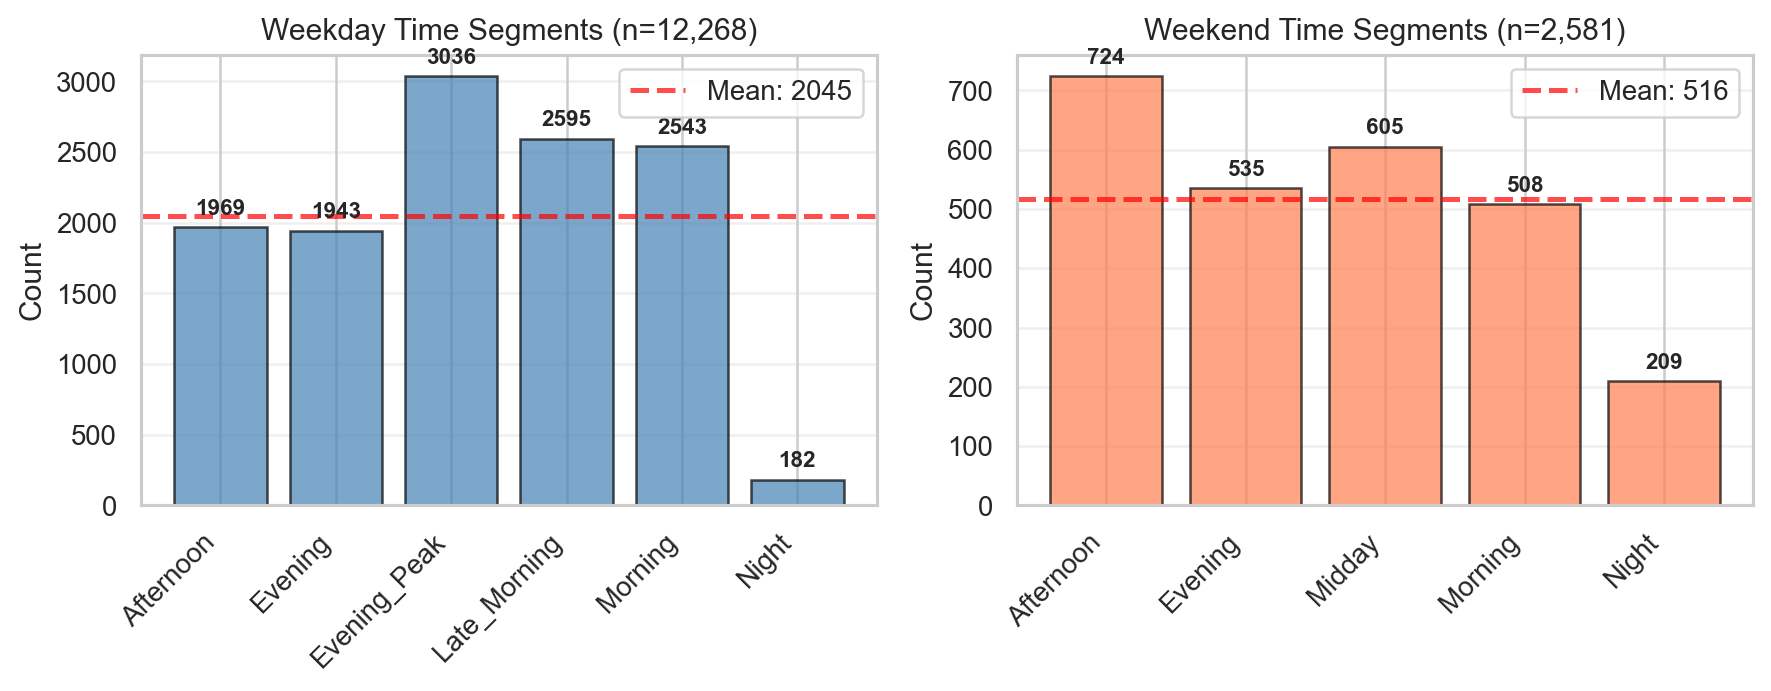


TIME BOUNDARIES BY DAY TYPE

WEEKDAY (6 periods):
  Night               : 00:00 - 05:00
  Morning             : 05:00 - 10:03
  Late_Morning        : 10:03 - 13:11
  Afternoon           : 13:11 - 16:20
  Evening_Peak        : 16:20 - 19:19
  Evening             : 19:19 - 23:59

WEEKEND (5 periods):
  Night               : 00:00 - 05:55
  Morning             : 05:55 - 11:04
  Midday              : 11:04 - 15:10
  Afternoon           : 15:10 - 19:19
  Evening             : 19:19 - 23:59

READY FOR CLUSTERING
Feature: 'time_segment'
Type: category
Unique categories: 7
Categories: ['Afternoon', 'Evening', 'Evening_Peak', 'Late_Morning', 'Midday', 'Morning', 'Night']

Note: 'Morning' means 5-10am on weekdays, 6-11am on weekends
      Same label, different context - clustering will learn this!


In [ ]:
# =============================================================================
# CREATE DAY-SPECIFIC TIME SEGMENTS
# =============================================================================

# First, ensure hour_continuous exists
df['hour_continuous'] = np.arctan2(
    df['time_sin'], df['time_cos']) * 24 / (2 * np.pi)
df['hour_continuous'] = df['hour_continuous'] % 24

# Define optimal Jenks breaks from our analysis
weekday_breaks = [0.00, 5.00, 10.05, 13.19, 16.34, 19.32, 23.99]
weekend_breaks = [0.00, 5.92, 11.08, 15.17, 19.33, 23.99]

# Create temporary day-specific labels
weekday_labels = ['Night', 'Morning', 'Late_Morning',
                  'Afternoon', 'Evening_Peak', 'Evening']
weekend_labels = ['Night', 'Morning', 'Midday', 'Afternoon', 'Evening']

# Create time segments separately for each day type (as string first)
df['time_segment'] = ''

# Weekday binning
weekday_mask = df['DAY_BINARY'] == 'Weekday'
df.loc[weekday_mask, 'time_segment'] = pd.cut(
    df.loc[weekday_mask, 'hour_continuous'],
    bins=weekday_breaks,
    labels=weekday_labels,
    include_lowest=True
).astype(str)

# Weekend binning
weekend_mask = df['DAY_BINARY'] == 'Weekend'
df.loc[weekend_mask, 'time_segment'] = pd.cut(
    df.loc[weekend_mask, 'hour_continuous'],
    bins=weekend_breaks,
    labels=weekend_labels,
    include_lowest=True
).astype(str)

# Check for any missing values
print("Missing values check:")
print(f"Empty strings: {(df['time_segment'] == '').sum()}")
print(f"NaN values: {df['time_segment'].isna().sum()}")

# If there are any empty strings or NaNs, investigate
if (df['time_segment'] == '').sum() > 0 or df['time_segment'].isna().sum() > 0:
    problematic = df[(df['time_segment'] == '') | (df['time_segment'].isna())]
    print(f"\nProblematic rows: {len(problematic)}")
    print(
        problematic[['DAY_BINARY', 'hour_continuous', 'time_segment']].head())

# Convert to categorical with only labels that exist
actual_labels = sorted(
    [label for label in df['time_segment'].unique() if label and label != 'nan'])
df['time_segment'] = pd.Categorical(
    df['time_segment'], categories=actual_labels, ordered=False)

print("="*80)
print("DAY-SPECIFIC TIME SEGMENTS")
print("="*80)

# Show distribution for each day type (filtering out zeros)
for day_type in ['Weekday', 'Weekend']:
    print(f"\n{day_type.upper()} TIME SEGMENTS:")
    subset = df[df['DAY_BINARY'] == day_type]

    # Get counts and filter out zeros
    counts = subset['time_segment'].value_counts()
    counts = counts[counts > 0].sort_index()

    for label, count in counts.items():
        pct = count / len(subset) * 100
        print(f"  {label:<20}: {count:>5} ({pct:>5.1f}%)")

    if len(counts) > 0:
        balance = counts.std() / counts.mean()
        ratio = counts.min() / counts.max()
        print(f"\n  Balance: {balance:.3f} | Min/Max ratio: {ratio:.3f}")

# Overall distribution
print("\n" + "="*80)
print("OVERALL DISTRIBUTION (All Days)")
print("="*80)
overall_counts = df['time_segment'].value_counts().sort_index()
for label, count in overall_counts.items():
    pct = count / len(df) * 100
    print(f"  {label:<20}: {count:>5} ({pct:>5.1f}%)")

# Show which labels are used by which day types
print("\n" + "="*80)
print("LABEL USAGE BY DAY TYPE")
print("="*80)
crosstab = pd.crosstab(df['DAY_BINARY'], df['time_segment'])
print(crosstab)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for idx, day_type in enumerate(['Weekday', 'Weekend']):
    ax = axes[idx]
    subset = df[df['DAY_BINARY'] == day_type]
    counts = subset['time_segment'].value_counts()
    counts = counts[counts > 0].sort_index()

    ax.bar(range(len(counts)), counts.values,
           color='steelblue' if day_type == 'Weekday' else 'coral',
           edgecolor='black', alpha=0.7)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=45, ha='right')
    ax.set_ylabel('Count')
    ax.set_title(f'{day_type} Time Segments (n={len(subset):,})')
    ax.grid(axis='y', alpha=0.3)

    # Add mean line
    ax.axhline(counts.mean(), color='red', linestyle='--',
               alpha=0.7, linewidth=2, label=f'Mean: {counts.mean():.0f}')

    # Add count labels
    for i, count in enumerate(counts.values):
        ax.text(i, count + max(counts.values)*0.02, str(count),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.legend()

plt.tight_layout()
plt.savefig('time_segments_by_day_type_clean.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Show time boundaries
print("\n" + "="*80)
print("TIME BOUNDARIES BY DAY TYPE")
print("="*80)
print("\nWEEKDAY (6 periods):")
for i, label in enumerate(weekday_labels):
    start_h, start_m = int(weekday_breaks[i]), int(
        (weekday_breaks[i] % 1) * 60)
    end_h, end_m = int(weekday_breaks[i+1]
                       ), int((weekday_breaks[i+1] % 1) * 60)
    print(f"  {label:<20}: {start_h:02d}:{start_m:02d} - {end_h:02d}:{end_m:02d}")

print("\nWEEKEND (5 periods):")
for i, label in enumerate(weekend_labels):
    start_h, start_m = int(weekend_breaks[i]), int(
        (weekend_breaks[i] % 1) * 60)
    end_h, end_m = int(weekend_breaks[i+1]
                       ), int((weekend_breaks[i+1] % 1) * 60)
    print(f"  {label:<20}: {start_h:02d}:{start_m:02d} - {end_h:02d}:{end_m:02d}")

print("\n" + "="*80)
print("READY FOR CLUSTERING")
print("="*80)
print(f"Feature: 'time_segment'")
print(f"Type: {df['time_segment'].dtype}")
print(f"Unique categories: {df['time_segment'].nunique()}")
print(f"Categories: {list(df['time_segment'].cat.categories)}")
print(f"\nNote: 'Morning' means 5-10am on weekdays, 6-11am on weekends")
print(f"      Same label, different context - clustering will learn this!")


**Weekday Balance: 0.490** - Good distribution

**Weekend Balance: 0.370** - Excellent, hits your target threshold

**Min/Max Ratios:**
- Weekend (0.289) is much healthier than Weekday (0.060)
- Weekday's low ratio is driven by the tiny Night bin, which is unavoidable - nighttime genuinely has minimal traffic

## Key Observations

**1. Time boundaries reveal behavioral patterns:**
- Weekday Evening_Peak: 4:20pm-7:19pm (commute home)
- Weekend Afternoon: 3:10pm-7:19pm (leisure, same clock time but different label)

**2. Label overlap shows conceptual similarity:**
- "Morning" exists for both but means different things (commute vs. leisure)
- "Evening" shares same hours (7:19pm-midnight) for both day types

**3. Unique periods capture day-specific patterns:**
- `Evening_Peak` and `Late_Morning` only exist on weekdays (work-related)
- `Midday` only exists on weekends (leisure period)

## Ready for Clustering

You now have a feature set that captures:
- **Day context**: `DAY_BINARY` (Weekday/Weekend)
- **Time context**: `time_segment` (7 categories, meaning shifts by day)
- **Circular time**: `time_sin`, `time_cos` (preserves cyclical nature)

**Next step:** Run your k-prototypes clustering with this feature set and compare cluster quality to your previous Binary (Weekend/Weekday) model. The hypothesis is that adding granular time segments will reveal more nuanced accident patterns within each day type.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14849 entries, 0 to 14848
Data columns (total 38 columns):
 #   Column                        Non-Null Count  Dtype                      
---  ------                        --------------  -----                      
 0   Protocollo                    14849 non-null  int64                      
 1   total_injury_severity         14849 non-null  int32                      
 2   max_injury_severity           14849 non-null  int32                      
 3   num_pedestrians_hit           14849 non-null  int64                      
 4   num_male                      14849 non-null  int32                      
 5   num_female                    14849 non-null  int32                      
 6   num_unknown_gender            14849 non-null  int32                      
 7   multiple_pedestrians          14849 non-null  int32                      
 8   severity_winsorized           14849 non-null  int32                      
 9   DataOraIncidente 

In [46]:
# Drop the temporary columns
df.drop(columns=['hour', 'hour_continuous'],
        inplace=True)

# Verify they're gone
print("Columns dropped successfully!")
print(f"New shape: {df.shape}")

Columns dropped successfully!
New shape: (14849, 36)


In [47]:
df['time_segment'].value_counts()

time_segment
Morning         3051
Evening_Peak    3036
Afternoon       2693
Late_Morning    2595
Evening         2478
Midday           605
Night            391
Name: count, dtype: int64

In [48]:
df.to_parquet('014_data_with_time_bins.parquet', index=False)

# CARDINALITY CHECK

In [49]:
# =============================================================================
# CATEGORICAL FEATURE CARDINALITY ANALYSIS
# =============================================================================

print("="*80)
print("CATEGORICAL FEATURE CARDINALITY")
print("="*80)

cardinality_summary = []

for feature in categorical_for_clustering:
    n_categories = df[feature].nunique()
    n_missing = df[feature].isna().sum()
    cardinality_summary.append({
        'Feature': feature,
        'Unique_Values': n_categories,
        'Missing': n_missing,
        'Missing_%': (n_missing / len(df)) * 100
    })

cardinality_df = pd.DataFrame(cardinality_summary)
cardinality_df = cardinality_df.sort_values('Unique_Values', ascending=False)
print(cardinality_df.to_string(index=False))

# Flag high cardinality features (>10 categories)
high_cardinality = cardinality_df[cardinality_df['Unique_Values'] > 10]
if len(high_cardinality) > 0:
    print("\n" + "="*80)
    print("⚠️  HIGH CARDINALITY FEATURES (>10 categories)")
    print("="*80)
    print(high_cardinality.to_string(index=False))
    print("\nConsider consolidating these features to reduce dimensionality.")

# Show distribution for each categorical feature
print("\n" + "="*80)
print("CATEGORICAL FEATURE DISTRIBUTIONS")
print("="*80)

for feature in categorical_for_clustering:
    print(f"\n{feature.upper()}")
    print("-" * 60)
    counts = df[feature].value_counts(dropna=False)

    # Show all if <=10 categories, otherwise top 10 + tail
    if len(counts) <= 10:
        for category, count in counts.items():
            pct = (count / len(df)) * 100
            print(f"  {str(category):<40}: {count:>6} ({pct:>5.1f}%)")
    else:
        print(
            f"  Showing top 10 and bottom 3 (total categories: {len(counts)})")
        print("\n  TOP 10:")
        for category, count in counts.head(10).items():
            pct = (count / len(df)) * 100
            print(f"  {str(category):<40}: {count:>6} ({pct:>5.1f}%)")

        print("\n  BOTTOM 3:")
        for category, count in counts.tail(3).items():
            pct = (count / len(df)) * 100
            print(f"  {str(category):<40}: {count:>6} ({pct:>5.1f}%)")

# Check for features with severe imbalance (one category >90%)
print("\n" + "="*80)
print("⚠️  SEVERELY IMBALANCED FEATURES (one category >90%)")
print("="*80)

imbalanced = []
for feature in categorical_for_clustering:
    counts = df[feature].value_counts()
    if len(counts) > 0:
        max_pct = (counts.max() / len(df)) * 100
        if max_pct > 90:
            imbalanced.append({
                'Feature': feature,
                'Dominant_Category': counts.index[0],
                'Percentage': max_pct
            })

if len(imbalanced) > 0:
    imbalanced_df = pd.DataFrame(imbalanced)
    print(imbalanced_df.to_string(index=False))
    print("\nThese features may not contribute much to clustering.")
else:
    print("None found - all features have reasonable balance.")

print("\n" + "="*80)
print("RECOMMENDATION")
print("="*80)
print("Ideal cardinality for k-prototypes: 2-10 categories per feature")
print("Consider consolidating features with >10 categories")
print("Consider removing features with >90% in one category")

CATEGORICAL FEATURE CARDINALITY
                     Feature  Unique_Values  Missing  Missing_%
                time_segment              7        0        0.0
                vehicle_type              6        0        0.0
         severity_winsorized              5        0        0.0
               road_features              4        0        0.0
        TipoStradaDifficulty              4        0        0.0
                road_signage              4        0        0.0
               driver_gender              3        0        0.0
               natural_light              3        0        0.0
             traffic_density              3        0        0.0
                  passengers              3        0        0.0
        multiple_pedestrians              2        0        0.0
               driver_injury              2        0        0.0
                  DAY_BINARY              2        0        0.0
road_markings_traffic_lights              2        0        0.0
        

# CLUSTERING WITH TIME BINS

In [51]:
# Numerical features for k-prototypes (continuous variables)
numerical_for_clustering = [
    # 'time_sin',
    # 'time_cos',
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'precipitation (mm)',
    'wind_gusts_10m (km/h)',
    'weather_days_since_last_rain',
    'male_proportion'
]

# Categorical features for k-prototypes (nominal/ordinal variables)
categorical_for_clustering = [
    'time_segment',  # Added: new time bins
    'multiple_pedestrians',
    'driver_injury',
    'driver_gender',
    'natural_light',
    'DAY_BINARY',
    'road_features',
    'road_markings_traffic_lights',
    'TipoStradaDifficulty',
    'traffic_density',
    'vehicle_type',
    'passengers',
    'road_conditions_bin',
    'road_signage',
    'severity_winsorized'
]

In [52]:
df_clustering = df[numerical_for_clustering + categorical_for_clustering]

In [53]:
df_clustering.shape

(14849, 21)

# FUNCTIONS FOR K-PROTOTYPES CLUSTERING

### FUNCTIONS FOR CLUSTER FITTING & EVALUATING

In [54]:
###############################
# PREPROCESSING DATA FUNCTION #
###############################

def preprocess_data(df, categorical_cols, numerical_cols):
    """
    Efficient preprocessing for K-Prototypes:
    - Categoricals: OrdinalEncoder → int32
    - Numericals: StandardScaler → float32
    """
    # Categorical encoding
    df_cat = df[categorical_cols].copy()
    df_cat = df_cat.astype("object").fillna("(missing)")

    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_cat = enc.fit_transform(df_cat)
    X_cat = np.where(np.isnan(X_cat), -1, X_cat)
    X_cat = X_cat.astype(np.int32, copy=False)

    # Create category mappings for later interpretation
    cat_maps = {col: {cat: i for i, cat in enumerate(enc.categories_[j])}
                for j, col in enumerate(categorical_cols)}
    rev_maps = {col: {i: cat for i, cat in enumerate(enc.categories_[j])}
                for j, col in enumerate(categorical_cols)}
    for col in categorical_cols:
        rev_maps[col][-1] = None

    # Numerical standardization
    X_num = df[numerical_cols].apply(pd.to_numeric, errors="coerce")
    num_medians = X_num.median(numeric_only=True)
    X_num = X_num.fillna(num_medians)

    scaler = StandardScaler()
    X_num_scaled = scaler.fit_transform(X_num).astype(np.float32, copy=False)

    # Combine: categoricals FIRST (critical for K-Prototypes)
    X = np.concatenate(
        [X_cat.astype(np.float32, copy=False), X_num_scaled], axis=1)
    categorical_indices = list(range(len(categorical_cols)))

    # Sanity checks
    assert X.dtype == np.float32, f"Expected float32, got {X.dtype}"
    assert np.isfinite(X).all(), "X contains NaN or inf values"

    print(f"\n✓ Preprocessing complete:")
    print(f"  Shape: {X.shape}")
    print(f"  Categorical features: {len(categorical_indices)}")
    print(f"  Numerical features: {len(numerical_cols)}")
    print(f"  dtype: {X.dtype}")

    return X, categorical_indices, enc, scaler, num_medians, rev_maps

##################
# ELBOW ANALYSIS #
##################


def elbow_analysis(X, categorical_indices, k_range, sample_size=df.shape[0], random_state=42):
    """
    Run K-Prototypes for multiple k values to find elbow point.
    Uses sampling to speed up computation.
    """
    # Sample data for faster computation
    rng = np.random.RandomState(random_state)
    n_samples = min(sample_size, X.shape[0])
    idx = rng.choice(X.shape[0], size=n_samples, replace=False)
    X_sample = X[idx]

    print(f"Using {n_samples} samples for elbow analysis...")

    costs = []
    for k in k_range:
        print(f"  Running k={k}...", end=" ")
        kp = KPrototypes(
            n_clusters=k,
            init="Cao",
            n_init=1,
            max_iter=20,
            random_state=random_state,
            verbose=0
        )
        kp.fit_predict(X_sample, categorical=categorical_indices)
        costs.append(kp.cost_)
        print(f"Cost: {kp.cost_:.2f}")

    # Calculate relative improvement
    cost_series = pd.Series(costs, index=k_range, name="cost")
    rel_improve = (-cost_series.diff() / cost_series.shift(1)
                   ).rename("rel_improve")
    elbow_df = pd.concat([cost_series, rel_improve], axis=1)

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 2))

    ax1.plot(k_range, costs, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax1.set_ylabel('Cost', fontsize=12)
    ax1.set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    ax2.plot(k_range[1:], rel_improve[1:], 'ro-', linewidth=2, markersize=8)
    ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax2.set_ylabel('Relative Improvement', fontsize=12)
    ax2.set_title('Cost Reduction Rate', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.05, color='green', linestyle='--',
                alpha=0.5, label='5% threshold')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return elbow_df

################
# GAMMA TUNING #
################


def gamma_tuning(X, categorical_indices, gammas, k=7, n_init=3, random_state=42):
    """
    Test different gamma values to balance categorical vs numerical importance.
    Higher gamma = more weight on categorical features.
    """
    print(f"Testing {len(gammas)} gamma values for k={k}...")

    results = []
    for g in gammas:
        print(f"  γ={g:.2f}...", end=" ")
        model = KPrototypes(
            n_clusters=k,
            init="Cao",
            n_init=n_init,
            max_iter=50,
            verbose=0,
            random_state=random_state,
            gamma=g
        )
        labels = model.fit_predict(X, categorical=categorical_indices)
        cost = model.cost_
        results.append({"gamma": g, "cost": cost})
        print(f"Cost: {cost:.2f}")

    results_df = pd.DataFrame(results).sort_values("cost")

    # Plot
    plt.figure(figsize=(8, 3))
    plt.plot(results_df['gamma'], results_df['cost'],
             'go-', linewidth=2, markersize=8)
    plt.xlabel('Gamma (γ)', fontsize=12)
    plt.ylabel('Cost', fontsize=12)
    plt.title('Gamma Tuning: Cost vs γ', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.show()

    return results_df

##################
# FIT & EVALUATE #
##################


def fit_and_evaluate(X, categorical_indices, k, gamma, enc, random_state=42):
    """
    Fit K-Prototypes and calculate multiple quality metrics.
    """
    print(f"\nFitting K-Prototypes: k={k}, γ={gamma}")
    print("This may take several minutes...")

    kproto = KPrototypes(
        n_clusters=k,
        init="Cao",
        gamma=gamma,
        n_init=5,
        max_iter=100,
        random_state=random_state,
        verbose=1
    )
    labels = kproto.fit_predict(X, categorical=categorical_indices)

    # Calculate metrics
    metrics = {}
    metrics['cost'] = kproto.cost_
    metrics['n_iter'] = kproto.n_iter_

    # Sample for silhouette (too slow on full dataset)
    sample_size = min(5000, X.shape[0])
    rng = np.random.RandomState(random_state)
    idx = rng.choice(X.shape[0], size=sample_size, replace=False)

    print("\nCalculating quality metrics (using sample)...")

    # Gower distance approximation for mixed data
    # Use only numerical features for standard metrics
    n_cat = len(categorical_indices)
    X_num = X[:, n_cat:]

    try:
        metrics['silhouette'] = silhouette_score(X_num[idx], labels[idx])
        metrics['calinski_harabasz'] = calinski_harabasz_score(X_num, labels)
        metrics['davies_bouldin'] = davies_bouldin_score(X_num, labels)
    except Exception as e:
        print(f"Warning: Could not calculate some metrics: {e}")
        metrics['silhouette'] = np.nan
        metrics['calinski_harabasz'] = np.nan
        metrics['davies_bouldin'] = np.nan

    # Cluster size balance
    sizes = pd.Series(labels).value_counts().sort_index()
    metrics['size_ratio'] = sizes.max() / sizes.min()
    metrics['min_cluster_size'] = sizes.min()
    metrics['max_cluster_size'] = sizes.max()

    print("\n" + "="*50)
    print("CLUSTERING QUALITY METRICS")
    print("="*50)
    print(f"Cost:                    {metrics['cost']:.2f}")
    print(f"Iterations:              {metrics['n_iter']}")
    print(
        f"Silhouette Score:        {metrics['silhouette']:.4f} (higher is better: -1 to 1)")
    print(
        f"Calinski-Harabasz:       {metrics['calinski_harabasz']:.2f} (higher is better)")
    print(
        f"Davies-Bouldin:          {metrics['davies_bouldin']:.4f} (lower is better)")
    print(f"Size Ratio (max/min):    {metrics['size_ratio']:.2f}")
    print(f"Cluster Sizes:           {sizes.min()} to {sizes.max()}")
    print("="*50)

    return kproto, labels, metrics, sizes

### FUNCTIONS FOR DECODING AND VIEWING CLUSTERS

In [55]:

####################
# DECODE CENTROIDS #
####################

def decode_centroids(kproto, enc, scaler, categorical_cols, numerical_cols, rev_maps):
    """
    Decode K-Prototypes centroids to interpretable format.

    Parameters:
    - kproto: Fitted KPrototypes model
    - enc: OrdinalEncoder used for categorical features
    - scaler: StandardScaler used for numerical features
    - categorical_cols: List of categorical column names
    - numerical_cols: List of numerical column names
    - rev_maps: Reverse mapping dictionary for categorical features
    """
    cc = kproto.cluster_centroids_
    n_cat = len(categorical_cols)
    n_num = len(numerical_cols)

    # KPrototypes stores centroids as [NUMERICAL, CATEGORICAL] regardless of input order!
    num_centroids = np.asarray(cc)[:, :n_num].astype(
        float)     # First n_num columns
    # Last n_cat columns
    cat_centroids = np.asarray(cc)[:, n_num:]

    # Inverse transform numerical centroids back to original scale
    num_centroids_original = scaler.inverse_transform(num_centroids)

    # Numerical centroids (rounded to 2 decimal places)
    num_centroids_df = pd.DataFrame(
        np.round(num_centroids_original, 2),
        columns=numerical_cols
    )

    # Decode categorical centroids - UPDATED VERSION
    def decode_cat(col, v):
        if pd.isna(v):
            return "(missing)"
        try:
            vi = int(round(float(v)))
        except:
            return "(missing)"

        decoded = rev_maps.get(col, {}).get(vi, "(missing)")

        # Convert None to a string
        if decoded is None:
            return "(missing)"

        # Convert everything to string for consistency
        return str(decoded)

    cat_centroids_df = pd.DataFrame({
        col: [decode_cat(col, v) for v in cat_centroids[:, j]]
        for j, col in enumerate(categorical_cols)
    })

    centroids_df = pd.concat([cat_centroids_df, num_centroids_df], axis=1)
    centroids_df.index.name = "cluster_id"

    return centroids_df

##########################
# CREATE CLUSTER SUMMARY #
##########################


def create_cluster_summary(df_enc, categorical_cols, numerical_cols):
    """
    Create comprehensive cluster summary statistics.
    """
    # Numerical means
    num_summary = df_enc.groupby("cluster_id")[numerical_cols].mean()

    # Categorical modes
    mode_summary = df_enc.groupby("cluster_id")[categorical_cols].agg(
        lambda s: s.value_counts(dropna=False).idxmax()
    )

    # Top 3 proportions for each categorical
    def top3_props(s):
        vc = s.value_counts(dropna=False, normalize=True)
        return " | ".join([f"{k}: {p:.1%}" for k, p in vc.head(3).items()])

    top3_summary = df_enc.groupby("cluster_id")[
        categorical_cols].agg(top3_props)

    # Combine
    summary = num_summary.join(mode_summary, rsuffix='_mode')

    return summary, top3_summary

#########################
# TOP LIFTS FOR CLUSTER #
#########################


def top_lifts_for_cluster(df_enc, cluster_id, cat_cols, topn=8, min_prop=0.07):
    """
    Identify distinctive categorical features for each cluster using lift.
    Lift = (proportion in cluster) / (proportion overall)
    """
    dfc = df_enc[df_enc["cluster_id"] == cluster_id]
    out = []

    for col in cat_cols:
        glob = df_enc[col].value_counts(normalize=True, dropna=False)
        clus = dfc[col].value_counts(normalize=True, dropna=False)

        for val, p_c in clus.items():
            p_g = glob.get(val, 0.0)
            if p_c >= min_prop and p_g > 0:
                lift = p_c / p_g
                out.append({
                    'feature': col,
                    'value': val,
                    'cluster_prop': round(p_c, 2),
                    'overall_prop': round(p_g, 2),
                    'lift': round(lift, 2)
                })

    lift_df = pd.DataFrame(out).sort_values(['lift', 'cluster_prop'],
                                            ascending=[False, False])
    return lift_df.head(topn)

# CLUSTERING WITH TIME BINS

## 

In [56]:
print("="*70)
print("K-PROTOTYPES CLUSTERING - PEDESTRIAN ACCIDENTS IN ROME")
print("="*70)

# Run preprocessing
X, categorical_indices, enc, scaler, num_medians, rev_maps = preprocess_data(
    df_clustering, categorical_for_clustering, numerical_for_clustering)

K-PROTOTYPES CLUSTERING - PEDESTRIAN ACCIDENTS IN ROME

✓ Preprocessing complete:
  Shape: (14849, 21)
  Categorical features: 15
  Numerical features: 6
  dtype: float32



ELBOW METHOD - Finding Optimal K
Using 14849 samples for elbow analysis...
  Running k=4... Cost: 82354.34
  Running k=5... Cost: 74063.12
  Running k=6... Cost: 69564.12
  Running k=7... Cost: 65644.56
  Running k=8... Cost: 63614.96
  Running k=9... Cost: 61808.67


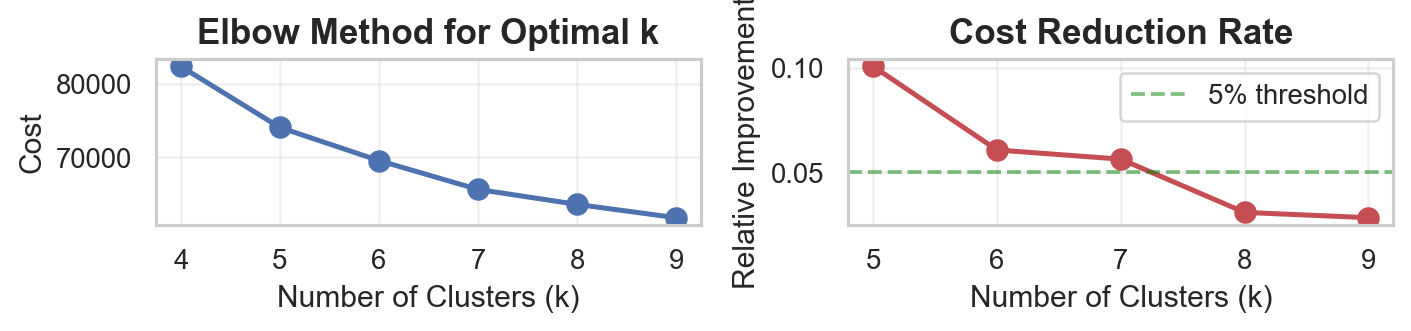


Elbow Analysis Results:
           cost  rel_improve
4  82354.339825          NaN
5  74063.118094     0.100677
6  69564.121690     0.060745
7  65644.555071     0.056345
8  63614.962339     0.030918
9  61808.667476     0.028394

Sorted by Relative Improvement:
           cost  rel_improve
5  74063.118094     0.100677
6  69564.121690     0.060745
7  65644.555071     0.056345
8  63614.962339     0.030918
9  61808.667476     0.028394
4  82354.339825          NaN


In [57]:
print("\n" + "="*70)
print("ELBOW METHOD - Finding Optimal K")
print("="*70)

# Run elbow analysis
K_range = list(range(4, 10))
elbow_df = elbow_analysis(X, categorical_indices, K_range)

print("\nElbow Analysis Results:")
print(elbow_df)
print("\nSorted by Relative Improvement:")
print(elbow_df.sort_values("rel_improve", ascending=False))

Given these results, we choose k = 7, as the marginal drops in cost fall below 5% after k=7. 

In [58]:
chosen_k = 7

In [ ]:
print("\n" + "="*70)
print("GAMMA TUNING")
print("="*70)

# Run gamma tuning (adjust k based on elbow results)
gammas = np.linspace(0.5, 2.5, 5)
gamma_results = gamma_tuning(X, categorical_indices, gammas, k=chosen_k)
print("\nGamma Tuning Results:")
print(gamma_results)

In [59]:
print("\n" + "="*70)
print("FINAL CLUSTERING & QUALITY ASSESSMENT")
print("="*70)

# Set your chosen gamma
chosen_gamma = 1.5  # Update based on gamma tuning

kproto, labels, metrics, cluster_sizes = fit_and_evaluate(
    X, categorical_indices, chosen_k, chosen_gamma, enc
)

# Add labels to dataframe
df_enc = df.copy()
df_enc["cluster_id"] = labels

print("\nCluster Sizes:")
print(cluster_sizes)


FINAL CLUSTERING & QUALITY ASSESSMENT

Fitting K-Prototypes: k=7, γ=1.5
This may take several minutes...
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 7936, ncost: 132230.70949544822
Run: 1, iteration: 2/100, moves: 3387, ncost: 129062.60656369013
Run: 1, iteration: 3/100, moves: 1963, ncost: 127029.34300326502
Run: 1, iteration: 4/100, moves: 1373, ncost: 126069.41917176676
Run: 1, iteration: 5/100, moves: 630, ncost: 125845.88808769383
Run: 1, iteration: 6/100, moves: 361, ncost: 125787.78997086216
Run: 1, iteration: 7/100, moves: 146, ncost: 125777.49590291257
Run: 1, iteration: 8/100, moves: 95, ncost: 125772.05140851189
Run: 1, iteration: 9/100, moves: 71, ncost: 125768.73780801125
Run: 1, iteration: 10/100, moves: 86, ncost: 125764.29319822224
Run: 1, iteration: 11/100, moves: 106, ncost: 125758.30243197505
Run: 1, iteration: 12/100, move

In [60]:
print("\n" + "="*70)
print("CLUSTER INTERPRETATION")
print("="*70)

centroids_pretty = decode_centroids(
    kproto, enc, scaler, categorical_for_clustering, numerical_for_clustering, rev_maps)
print("\nCluster Centroids:")
print(centroids_pretty.T)


CLUSTER INTERPRETATION

Cluster Centroids:
cluster_id                                0              1              2  \
time_segment                   Late_Morning        Morning      Afternoon   
multiple_pedestrians                      0              0              0   
driver_injury                             0              0              0   
driver_gender                             M              M              M   
natural_light                     light_day      light_day      light_day   
DAY_BINARY                          Weekday        Weekday        Weekday   
road_features                 Straight road  Straight road  Straight road   
road_markings_traffic_lights              0              0              0   
TipoStradaDifficulty                      2              2              2   
traffic_density                           1              1              1   
vehicle_type                            Car            Car            Car   
passengers                      

In [61]:
summary, top3_summary = create_cluster_summary(
    df_enc, categorical_for_clustering, numerical_for_clustering)

print("\nCluster Summary (Numerical Means + Categorical Modes):")
print(summary.T)

print("\nTop 3 Categories per Cluster:")
print(top3_summary.T)


Cluster Summary (Numerical Means + Categorical Modes):
cluster_id                                0              1              2  \
temperature_2m (°C)               23.241899      13.522931      15.819109   
relative_humidity_2m (%)          51.347781      78.516179      69.043376   
precipitation (mm)                  0.01806       0.023024       0.001993   
wind_gusts_10m (km/h)             27.332577      14.876322      16.626964   
weather_days_since_last_rain       2.636739       2.127891      14.127003   
male_proportion                    0.016455       0.981658       0.451544   
time_segment                   Late_Morning        Morning      Afternoon   
multiple_pedestrians                      0              0              0   
driver_injury                             0              0              0   
driver_gender                             M              M              M   
natural_light                     light_day      light_day      light_day   
DAY_BINARY          

In [62]:
print("\n" + "="*70)
print("DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)")
print("="*70)

distinctive = {
    k: top_lifts_for_cluster(df_enc, k, categorical_for_clustering)
    for k in sorted(df_enc["cluster_id"].unique())
}

for cluster_id, lift_df in distinctive.items():
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_id} - Most Distinctive Features")
    print(f"{'='*50}")
    print(lift_df.to_string(index=False))


DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)

CLUSTER 0 - Most Distinctive Features
             feature        value  cluster_prop  overall_prop  lift
        time_segment Late_Morning          0.31          0.17  1.77
        time_segment    Afternoon          0.26          0.18  1.43
       natural_light    light_day          0.96          0.69  1.38
 road_conditions_bin            0          0.91          0.76  1.20
       driver_gender            F          0.23          0.21  1.11
multiple_pedestrians            1          0.08          0.07  1.10
     traffic_density            1          0.73          0.67  1.09
TipoStradaDifficulty            1          0.27          0.25  1.08

CLUSTER 1 - Most Distinctive Features
            feature          value  cluster_prop  overall_prop  lift
       time_segment        Morning          0.32          0.21  1.56
      natural_light    light_night          0.23          0.15  1.51
      natural_light light_twilight          0.21      

# Traffic Incident Cluster Analysis Summary
Time segments in, 

K-Prototypes  
k                           7  
gamma                       1.5  
Cost:                       125206.98
Iterations:                 19
Silhouette Score:           0.2089 (higher is better: -1 to 1)      Moderate separation
Calinski-Harabasz:          3212.03 (higher is better)
Davies-Bouldin:             1.4058 (lower is better)
Size Ratio (max/min):       7.61                                    Significant size imbalance
Cluster Sizes:              432 to 3287

In [63]:
print("\n" + "="*70)
print("EXPORTING RESULTS")
print("="*70)

# Save summary
output_path = r"C:\Users\lucyq\Dropbox\AMDP\THESIS\k7-g15-Timebins.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    summary.to_excel(writer, sheet_name='Summary')
    top3_summary.to_excel(writer, sheet_name='Top3_Proportions')
    centroids_pretty.to_excel(writer, sheet_name='Centroids')
    pd.DataFrame([metrics]).to_excel(writer, sheet_name='Metrics', index=False)
    cluster_sizes.to_frame('size').to_excel(writer, sheet_name='Cluster_Sizes')

print(f"✓ Results saved to: {output_path}")

# Save cluster assignments
df_enc[['cluster_id']].to_csv(
    r"C:\Users\lucyq\Dropbox\AMDP\THESIS\cluster_k7-g15-Timebins.csv"
)
print("✓ Cluster assignments saved")

print("\n" + "="*70)
print("CLUSTERING COMPLETE!")
print("="*70)


EXPORTING RESULTS
✓ Results saved to: C:\Users\lucyq\Dropbox\AMDP\THESIS\k7-g15-Timebins.xlsx
✓ Cluster assignments saved

CLUSTERING COMPLETE!


## REMOVING REDUNDANT FEATURES

The features which are continuously coming out the same for every cluster are:
- multiple pedestrians
- driver injury
- road features
- road markings traffic lights
- passengers
- road signage

We will try removing these features from the dataframe and reclustering:

In [ ]:
# Numerical features for k-prototypes (continuous variables)
numerical_for_clustering = [
    # 'time_sin',
    # 'time_cos',
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'precipitation (mm)',
    'wind_gusts_10m (km/h)',
    'weather_days_since_last_rain',
    'male_proportion'
]

# Categorical features for k-prototypes (nominal/ordinal variables)
categorical_for_clustering = [
    'time_segment',  # Added: new time bins
    # 'multiple_pedestrians',
    # 'driver_injury',
    'driver_gender',
    'natural_light',
    'DAY_BINARY',
    # 'road_features',
    # 'road_markings_traffic_lights',
    'TipoStradaDifficulty',
    'traffic_density',
    'vehicle_type',
    # 'passengers',
    'road_conditions_bin',
    # 'road_signage',
    'severity_winsorized'
]

In [65]:
df_clustering = df[numerical_for_clustering + categorical_for_clustering]

In [66]:
df_clustering.shape

(14849, 15)

In [67]:
print("="*70)
print("K-PROTOTYPES CLUSTERING - PEDESTRIAN ACCIDENTS IN ROME")
print("="*70)

# Run preprocessing
X, categorical_indices, enc, scaler, num_medians, rev_maps = preprocess_data(
    df_clustering, categorical_for_clustering, numerical_for_clustering)

K-PROTOTYPES CLUSTERING - PEDESTRIAN ACCIDENTS IN ROME

✓ Preprocessing complete:
  Shape: (14849, 15)
  Categorical features: 9
  Numerical features: 6
  dtype: float32



ELBOW METHOD - Finding Optimal K
Using 14849 samples for elbow analysis...
  Running k=4... Cost: 75158.84
  Running k=5... Cost: 66867.62
  Running k=6... Cost: 62368.63
  Running k=7... Cost: 58429.79
  Running k=8... Cost: 56391.61
  Running k=9... Cost: 54554.64


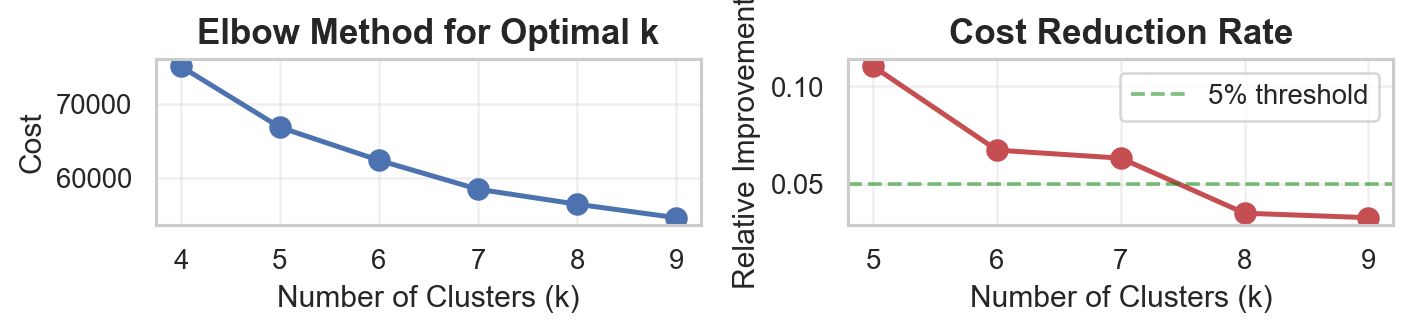


Elbow Analysis Results:
           cost  rel_improve
4  75158.839820          NaN
5  66867.618089     0.110316
6  62368.629051     0.067282
7  58429.793181     0.063154
8  56391.609627     0.034883
9  54554.635689     0.032575

Sorted by Relative Improvement:
           cost  rel_improve
5  66867.618089     0.110316
6  62368.629051     0.067282
7  58429.793181     0.063154
8  56391.609627     0.034883
9  54554.635689     0.032575
4  75158.839820          NaN


In [68]:
print("\n" + "="*70)
print("ELBOW METHOD - Finding Optimal K")
print("="*70)

# Run elbow analysis
K_range = list(range(4, 10))
elbow_df = elbow_analysis(X, categorical_indices, K_range)

print("\nElbow Analysis Results:")
print(elbow_df)
print("\nSorted by Relative Improvement:")
print(elbow_df.sort_values("rel_improve", ascending=False))

Given these results, we again choose k = 7, as the marginal drops in cost fall below 5% after k=7. 

In [69]:
chosen_k = 7


GAMMA TUNING
Testing 5 gamma values for k=7...
  γ=0.50... Cost: 58390.97
  γ=1.00... Cost: 80845.29
  γ=1.50... Cost: 103294.45
  γ=2.00... Cost: 126727.84
  γ=2.50... Cost: 146546.14


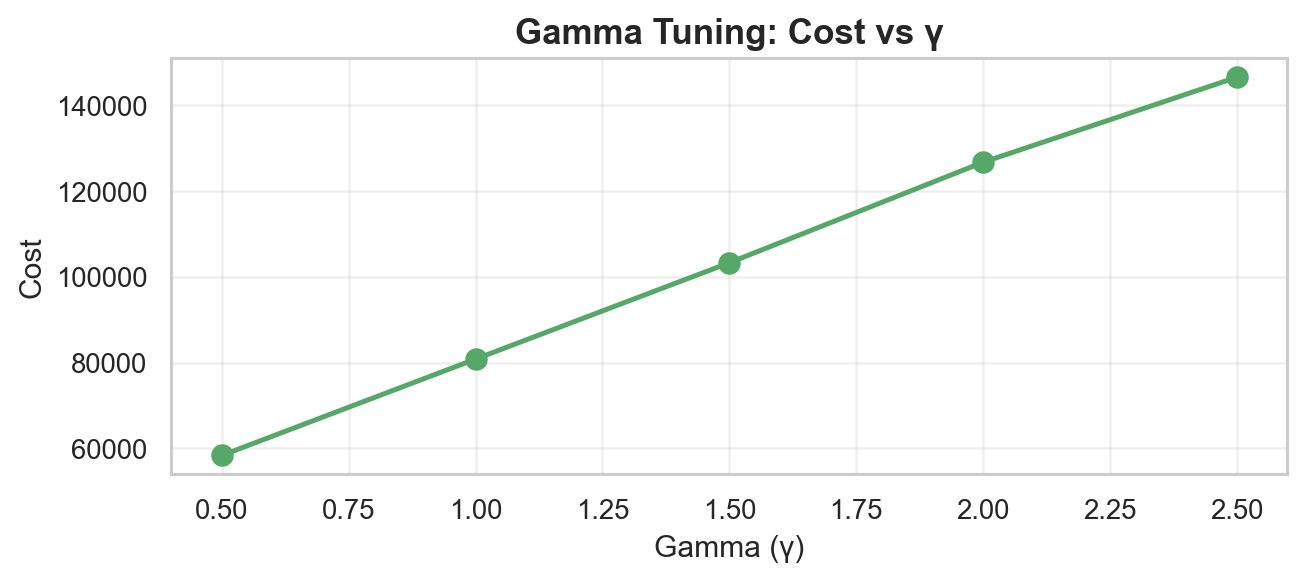


Gamma Tuning Results:
   gamma           cost
0    0.5   58390.971720
1    1.0   80845.290299
2    1.5  103294.447837
3    2.0  126727.838425
4    2.5  146546.144047


In [70]:
print("\n" + "="*70)
print("GAMMA TUNING")
print("="*70)

# Run gamma tuning (adjust k based on elbow results)
gammas = np.linspace(0.5, 2.5, 5)
gamma_results = gamma_tuning(X, categorical_indices, gammas, k=chosen_k)
print("\nGamma Tuning Results:")
print(gamma_results)

In [71]:
print("\n" + "="*70)
print("FINAL CLUSTERING & QUALITY ASSESSMENT")
print("="*70)

# Set your chosen gamma
chosen_gamma = 1.5  # Update based on gamma tuning

kproto, labels, metrics, cluster_sizes = fit_and_evaluate(
    X, categorical_indices, chosen_k, chosen_gamma, enc
)

# Add labels to dataframe
df_enc = df.copy()
df_enc["cluster_id"] = labels

print("\nCluster Sizes:")
print(cluster_sizes)


FINAL CLUSTERING & QUALITY ASSESSMENT

Fitting K-Prototypes: k=7, γ=1.5
This may take several minutes...
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 6923, ncost: 111129.8255916612
Run: 1, iteration: 2/100, moves: 2948, ncost: 108031.50420634152
Run: 1, iteration: 3/100, moves: 2070, ncost: 106310.26634250347
Run: 1, iteration: 4/100, moves: 1508, ncost: 104582.20833005135
Run: 1, iteration: 5/100, moves: 993, ncost: 104310.42850741261
Run: 1, iteration: 6/100, moves: 528, ncost: 104190.60584310857
Run: 1, iteration: 7/100, moves: 413, ncost: 104126.80722044173
Run: 1, iteration: 8/100, moves: 252, ncost: 104099.19315270933
Run: 1, iteration: 9/100, moves: 194, ncost: 104080.02126381842
Run: 1, iteration: 10/100, moves: 131, ncost: 104070.28542510039
Run: 1, iteration: 11/100, moves: 126, ncost: 104061.68604205092
Run: 1, iteration: 12/100, mo

In [72]:
print("\n" + "="*70)
print("CLUSTER INTERPRETATION")
print("="*70)

centroids_pretty = decode_centroids(
    kproto, enc, scaler, categorical_for_clustering, numerical_for_clustering, rev_maps)
print("\nCluster Centroids:")
print(centroids_pretty.T)


CLUSTER INTERPRETATION

Cluster Centroids:
cluster_id                               0             1          2  \
time_segment                  Late_Morning  Evening_Peak    Morning   
driver_gender                            M             M          M   
natural_light                    light_day     light_day  light_day   
DAY_BINARY                         Weekday       Weekday    Weekday   
TipoStradaDifficulty                     2             2          2   
traffic_density                          1             1          1   
vehicle_type                           Car           Car        Car   
road_conditions_bin                      0             1          0   
severity_winsorized                      1             1          1   
temperature_2m (°C)                  23.65         12.94      11.86   
relative_humidity_2m (%)             50.53         78.74      79.47   
precipitation (mm)                    0.01          0.34       0.03   
wind_gusts_10m (km/h)            

In [73]:
summary, top3_summary = create_cluster_summary(
    df_enc, categorical_for_clustering, numerical_for_clustering)

print("\nCluster Summary (Numerical Means + Categorical Modes):")
print(summary.T)

print("\nTop 3 Categories per Cluster:")
print(top3_summary.T)


Cluster Summary (Numerical Means + Categorical Modes):
cluster_id                               0             1          2  \
temperature_2m (°C)              23.649558     12.939952  11.863647   
relative_humidity_2m (%)         50.530223     78.736817  79.474457   
precipitation (mm)                0.010428       0.33962   0.025713   
wind_gusts_10m (km/h)            26.253022     33.370499  15.739515   
weather_days_since_last_rain      2.879772      0.300911   1.822902   
male_proportion                   0.014139      0.512549   0.199054   
time_segment                  Late_Morning  Evening_Peak    Morning   
driver_gender                            M             M          M   
natural_light                    light_day     light_day  light_day   
DAY_BINARY                         Weekday       Weekday    Weekday   
TipoStradaDifficulty                     2             2          2   
traffic_density                          1             1          1   
vehicle_type         

In [74]:
print("\n" + "="*70)
print("DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)")
print("="*70)

distinctive = {
    k: top_lifts_for_cluster(df_enc, k, categorical_for_clustering)
    for k in sorted(df_enc["cluster_id"].unique())
}

for cluster_id, lift_df in distinctive.items():
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_id} - Most Distinctive Features")
    print(f"{'='*50}")
    print(lift_df.to_string(index=False))


DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)

CLUSTER 0 - Most Distinctive Features
             feature        value  cluster_prop  overall_prop  lift
        time_segment Late_Morning          0.31          0.17  1.76
        time_segment    Afternoon          0.26          0.18  1.42
       natural_light    light_day          0.96          0.69  1.38
 road_conditions_bin            0          0.94          0.76  1.24
       driver_gender            F          0.24          0.21  1.12
     traffic_density            1          0.73          0.67  1.08
TipoStradaDifficulty            1          0.27          0.25  1.07
          DAY_BINARY      Weekday          0.86          0.83  1.04

CLUSTER 1 - Most Distinctive Features
             feature                 value  cluster_prop  overall_prop  lift
 road_conditions_bin                     1          0.82          0.24  3.47
        time_segment          Evening_Peak          0.36          0.20  1.74
       natural_light        li

# Traffic Incident Cluster Analysis Summary
Time segments in, features removed: multiple pedestrians, driver injury, road features, road markings traffic lights, passengers, road signage

K-Prototypes  
k                           7  
gamma                       1.5  
Cost:                       103294.45
Iterations:                 49
Silhouette Score:           0.1599 (higher is better: -1 to 1)      Moderate separation
Calinski-Harabasz:          2833.40 (higher is better)
Davies-Bouldin:             1.5143 (lower is better)
Size Ratio (max/min):       9.06                                    Significant size imbalance
Cluster Sizes:              391 to 3543

This made the clustering worse, not better! 

In [75]:
print("\n" + "="*70)
print("EXPORTING RESULTS")
print("="*70)

# Save summary
output_path = r"C:\Users\lucyq\Dropbox\AMDP\THESIS\k7-g15-features_removed.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    summary.to_excel(writer, sheet_name='Summary')
    top3_summary.to_excel(writer, sheet_name='Top3_Proportions')
    centroids_pretty.to_excel(writer, sheet_name='Centroids')
    pd.DataFrame([metrics]).to_excel(writer, sheet_name='Metrics', index=False)
    cluster_sizes.to_frame('size').to_excel(writer, sheet_name='Cluster_Sizes')

print(f"✓ Results saved to: {output_path}")

# Save cluster assignments
df_enc[['cluster_id']].to_csv(
    r"C:\Users\lucyq\Dropbox\AMDP\THESIS\cluster_k7-g15-features_removed.csv"
)
print("✓ Cluster assignments saved")

print("\n" + "="*70)
print("CLUSTERING COMPLETE!")
print("="*70)


EXPORTING RESULTS
✓ Results saved to: C:\Users\lucyq\Dropbox\AMDP\THESIS\k7-g15-features_removed.xlsx
✓ Cluster assignments saved

CLUSTERING COMPLETE!


## REMOVING MORE FEATURES

The features which are continuously coming out the same for every cluster are:
- vehicle type
- traffic density
- tipo strada difficulty
- driver gender

We will try removing these features from the dataframe and reclustering:

In [ ]:
# Numerical features for k-prototypes (continuous variables)
numerical_for_clustering = [
    # 'time_sin',
    # 'time_cos',
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'precipitation (mm)',
    'wind_gusts_10m (km/h)',
    'weather_days_since_last_rain',
    'male_proportion'
]

# Categorical features for k-prototypes (nominal/ordinal variables)
categorical_for_clustering = [
    'time_segment',  # Added: new time bins
    # 'multiple_pedestrians',
    # 'driver_injury',
    # 'driver_gender',
    'natural_light',
    'DAY_BINARY',
    # 'road_features',
    # 'road_markings_traffic_lights',
    # 'TipoStradaDifficulty',
    # 'traffic_density',
    # 'vehicle_type',
    # 'passengers',
    'road_conditions_bin',
    # 'road_signage',
    'severity_winsorized'
]

In [77]:
df_clustering = df[numerical_for_clustering + categorical_for_clustering]

In [78]:
df_clustering.shape

(14849, 11)

In [79]:
print("="*70)
print("K-PROTOTYPES CLUSTERING - PEDESTRIAN ACCIDENTS IN ROME")
print("="*70)

# Run preprocessing
X, categorical_indices, enc, scaler, num_medians, rev_maps = preprocess_data(
    df_clustering, categorical_for_clustering, numerical_for_clustering)

K-PROTOTYPES CLUSTERING - PEDESTRIAN ACCIDENTS IN ROME

✓ Preprocessing complete:
  Shape: (14849, 11)
  Categorical features: 5
  Numerical features: 6
  dtype: float32



ELBOW METHOD - Finding Optimal K
Using 14849 samples for elbow analysis...
  Running k=4... Cost: 64452.34
  Running k=5... Cost: 56161.12
  Running k=6... Cost: 51662.13
  Running k=7... Cost: 47723.29
  Running k=8... Cost: 45712.96
  Running k=9... Cost: 43779.43


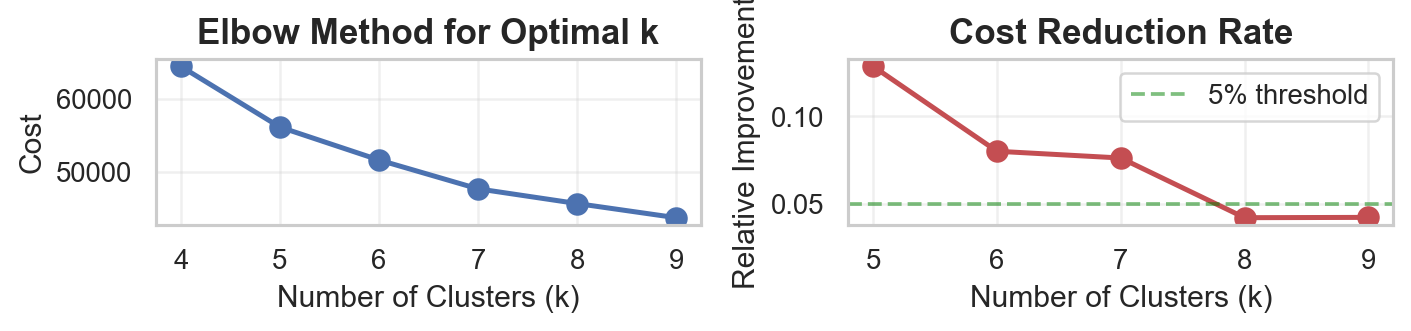


Elbow Analysis Results:
           cost  rel_improve
4  64452.339813          NaN
5  56161.118082     0.128641
6  51662.129044     0.080109
7  47723.293174     0.076242
8  45712.962327     0.042125
9  43779.426564     0.042297

Sorted by Relative Improvement:
           cost  rel_improve
5  56161.118082     0.128641
6  51662.129044     0.080109
7  47723.293174     0.076242
9  43779.426564     0.042297
8  45712.962327     0.042125
4  64452.339813          NaN


In [80]:
print("\n" + "="*70)
print("ELBOW METHOD - Finding Optimal K")
print("="*70)

# Run elbow analysis
K_range = list(range(4, 10))
elbow_df = elbow_analysis(X, categorical_indices, K_range)

print("\nElbow Analysis Results:")
print(elbow_df)
print("\nSorted by Relative Improvement:")
print(elbow_df.sort_values("rel_improve", ascending=False))

Given these results, we again choose k = 7, as the marginal drops in cost fall below 5% after k=7. 

In [81]:
chosen_k = 7


GAMMA TUNING
Testing 5 gamma values for k=7...
  γ=0.50... Cost: 47685.43
  γ=1.00... Cost: 59490.71
  γ=1.50... Cost: 71912.53
  γ=2.00... Cost: 83780.88
  γ=2.50... Cost: 93739.27


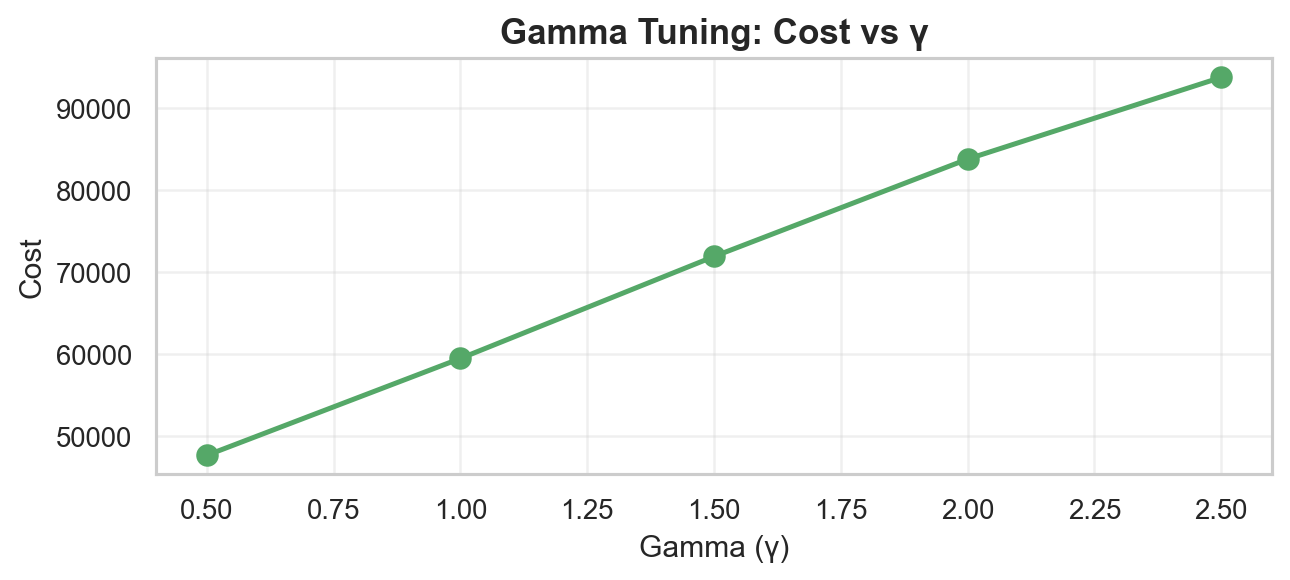


Gamma Tuning Results:
   gamma          cost
0    0.5  47685.427402
1    1.0  59490.708198
2    1.5  71912.525885
3    2.0  83780.875992
4    2.5  93739.273689


In [82]:
print("\n" + "="*70)
print("GAMMA TUNING")
print("="*70)

# Run gamma tuning (adjust k based on elbow results)
gammas = np.linspace(0.5, 2.5, 5)
gamma_results = gamma_tuning(X, categorical_indices, gammas, k=chosen_k)
print("\nGamma Tuning Results:")
print(gamma_results)

In [83]:
print("\n" + "="*70)
print("FINAL CLUSTERING & QUALITY ASSESSMENT")
print("="*70)

# Set your chosen gamma
chosen_gamma = 1.5  # Update based on gamma tuning

kproto, labels, metrics, cluster_sizes = fit_and_evaluate(
    X, categorical_indices, chosen_k, chosen_gamma, enc
)

# Add labels to dataframe
df_enc = df.copy()
df_enc["cluster_id"] = labels

print("\nCluster Sizes:")
print(cluster_sizes)


FINAL CLUSTERING & QUALITY ASSESSMENT

Fitting K-Prototypes: k=7, γ=1.5
This may take several minutes...
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 5988, ncost: 77918.53178707804
Run: 1, iteration: 2/100, moves: 2628, ncost: 75657.65228692832
Run: 1, iteration: 3/100, moves: 2336, ncost: 73052.52658112672
Run: 1, iteration: 4/100, moves: 1310, ncost: 72435.55380805417
Run: 1, iteration: 5/100, moves: 787, ncost: 72170.63126499437
Run: 1, iteration: 6/100, moves: 523, ncost: 72054.14745802255
Run: 1, iteration: 7/100, moves: 418, ncost: 71986.86162321581
Run: 1, iteration: 8/100, moves: 276, ncost: 71956.11054882045
Run: 1, iteration: 9/100, moves: 155, ncost: 71943.03018464788
Run: 1, iteration: 10/100, moves: 144, ncost: 71932.29511651909
Run: 1, iteration: 11/100, moves: 122, ncost: 71924.3988098991
Run: 1, iteration: 12/100, moves: 114, n

In [84]:
print("\n" + "="*70)
print("CLUSTER INTERPRETATION")
print("="*70)

centroids_pretty = decode_centroids(
    kproto, enc, scaler, categorical_for_clustering, numerical_for_clustering, rev_maps)
print("\nCluster Centroids:")
print(centroids_pretty.T)


CLUSTER INTERPRETATION

Cluster Centroids:
cluster_id                            0             1             2  \
time_segment                    Morning  Evening_Peak  Late_Morning   
natural_light                 light_day     light_day     light_day   
DAY_BINARY                      Weekday       Weekday       Weekday   
road_conditions_bin                   0             0             0   
severity_winsorized                   1             1             1   
temperature_2m (°C)               13.24         15.56         23.92   
relative_humidity_2m (%)          79.29         69.94         50.26   
precipitation (mm)                 0.03           0.0          0.01   
wind_gusts_10m (km/h)             14.78         16.55         26.23   
weather_days_since_last_rain       2.03          14.3          2.88   
male_proportion                    0.98          0.46          0.02   

cluster_id                               3             4          5          6  
time_segment          

In [85]:
summary, top3_summary = create_cluster_summary(
    df_enc, categorical_for_clustering, numerical_for_clustering)

print("\nCluster Summary (Numerical Means + Categorical Modes):")
print(summary.T)

print("\nTop 3 Categories per Cluster:")
print(top3_summary.T)


Cluster Summary (Numerical Means + Categorical Modes):
cluster_id                            0             1             2  \
temperature_2m (°C)           13.244074     15.559877     23.917465   
relative_humidity_2m (%)      79.289529      69.93865     50.264186   
precipitation (mm)             0.030903      0.002086       0.01028   
wind_gusts_10m (km/h)         14.781068     16.550307     26.228408   
weather_days_since_last_rain   2.028053     14.299591      2.881095   
male_proportion                0.982103      0.462781      0.015967   
time_segment                    Morning  Evening_Peak  Late_Morning   
natural_light                 light_day     light_day     light_day   
DAY_BINARY                      Weekday       Weekday       Weekday   
road_conditions_bin                   0             0             0   
severity_winsorized                   1             1             1   

cluster_id                               3             4          5          6  
temperatur

In [86]:
print("\n" + "="*70)
print("DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)")
print("="*70)

distinctive = {
    k: top_lifts_for_cluster(df_enc, k, categorical_for_clustering)
    for k in sorted(df_enc["cluster_id"].unique())
}

for cluster_id, lift_df in distinctive.items():
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_id} - Most Distinctive Features")
    print(f"{'='*50}")
    print(lift_df.to_string(index=False))


DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)

CLUSTER 0 - Most Distinctive Features
            feature          value  cluster_prop  overall_prop  lift
      natural_light    light_night          0.28          0.15  1.87
       time_segment        Evening          0.27          0.17  1.61
       time_segment        Morning          0.30          0.21  1.47
      natural_light light_twilight          0.21          0.16  1.33
         DAY_BINARY        Weekend          0.20          0.17  1.17
severity_winsorized              0          0.14          0.13  1.08
road_conditions_bin              0          0.81          0.76  1.07
severity_winsorized              2          0.07          0.07  1.00

CLUSTER 1 - Most Distinctive Features
            feature          value  cluster_prop  overall_prop  lift
road_conditions_bin              0          0.97          0.76  1.28
      natural_light light_twilight          0.19          0.16  1.24
severity_winsorized              2          0

# Traffic Incident Cluster Analysis Summary
Time segments in, features removed: vehicle type, traffic density, tipo strada difficulty, 

K-Prototypes  
k                           7  
gamma                       1.5  
Cost:                       70935.22
Iterations:                 16
Silhouette Score:           0.2296 (higher is better: -1 to 1)      Moderate separation, improved
Calinski-Harabasz:          3428.12 (higher is better)              Better
Davies-Bouldin:             1.2918 (lower is better)                Better
Size Ratio (max/min):       8.77                                    Significant size imbalance
Cluster Sizes:              380 to 3333

This made the clustering a little better! 

In [87]:
print("\n" + "="*70)
print("EXPORTING RESULTS")
print("="*70)

# Save summary
output_path = r"C:\Users\lucyq\Dropbox\AMDP\THESIS\k7-g15-more-features_removed.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    summary.to_excel(writer, sheet_name='Summary')
    top3_summary.to_excel(writer, sheet_name='Top3_Proportions')
    centroids_pretty.to_excel(writer, sheet_name='Centroids')
    pd.DataFrame([metrics]).to_excel(writer, sheet_name='Metrics', index=False)
    cluster_sizes.to_frame('size').to_excel(writer, sheet_name='Cluster_Sizes')

print(f"✓ Results saved to: {output_path}")

# Save cluster assignments
df_enc[['cluster_id']].to_csv(
    r"C:\Users\lucyq\Dropbox\AMDP\THESIS\cluster_k7-g15-more-features_removed.csv"
)
print("✓ Cluster assignments saved")

print("\n" + "="*70)
print("CLUSTERING COMPLETE!")
print("="*70)


EXPORTING RESULTS
✓ Results saved to: C:\Users\lucyq\Dropbox\AMDP\THESIS\k7-g15-more-features_removed.xlsx
✓ Cluster assignments saved

CLUSTERING COMPLETE!
